# SSL Objectives on Medical Images — a controlled comparison

**Question:** *holding the encoder backbone and compute budget fixed, how do different
self-supervised pretraining objectives compare as medical-image representation learners,
and at what "abstraction level" (diffusion timestep) does the denoising objective peak?*

Arms (all share **one** encoder class + config):

1. **Diffusion / denoising** — a small DDPM whose denoiser reuses the shared trunk (the OrthoDiffusion mechanism).
2. **MAE / SimMIM** — masked pixel reconstruction with the same trunk + a light conv decoder.
3. **JEPA (phase 2)** — latent prediction; implemented but **disabled by default** in the config.

Downstream, identical for every arm: freeze encoder → linear probe, then fine-tune,
plus a diffusion **timestep ablation** that should show the rise-then-fall AUROC-vs-`t` curve.

---

## Hard invariants enforced in this notebook

| # | Invariant | Where it is enforced |
|---|-----------|----------------------|
| I1 | One shared encoder class/config for every arm | `Encoder`, `assert_param_parity()` (M1) |
| I2 | One feature-extraction site (encoder bottleneck), only `t` varies | `Encoder.extract()`, `extract_features()` |
| I3 | Pretraining sees the official train split only, **unlabeled** | `UnlabeledImageDataset` + `label_blind()` guard |
| I4 | Matched compute budget (equal optimizer steps, same optimizer/schedule) | `pretrain_arm()` — steps/LR come from one config block |
| I5 | Matched downstream protocol (identical probe & finetune recipes) | `linear_probe()`, `finetune()` — recipe args come from config, never per-arm |
| I6 | Honest test discipline: seed list, mean ± std, val-for-selection, test once | `CFG.eval.seeds`, `metrics.py` cell, `select_best_*` helpers |

**Hardware target:** Apple Silicon / PyTorch MPS, 2D, ≤64×64, single process.

---

## How to run

1. Run the *Setup* cells (install, config, utils, data, backbone) top to bottom.
2. Leave `SMOKE = True` for the first pass — it runs the entire pipeline end-to-end in a few
   minutes on a subset so you can prove nothing is broken. Then set `SMOKE = False` and
   **Restart & Run All** for the real run.
3. Milestones **M0 … M7** are the numbered sections below; each one is self-contained and
   writes its outputs to `results/`.

Everything is checkpointed to `checkpoints/`, so re-running a milestone cell does not
re-train anything that already finished (pass `force=True` to override).

**Measured runtime** (M-series laptop, MPS, batch 128 @ 64px): ~0.43 s/step for the diffusion
arm and ~0.37 s/step for MAE, so the default 4000-step budget is ≈30 min per arm per seed —
about 3 h for the full `2 arms × 3 seeds` grid, plus ~30 min for the fine-tunes, baselines and
the timestep sweep. `SMOKE = True` runs the same code path in ~2 min. If 3 h is too much,
set `eval.seeds: [0]` (you then lose the ± std) or halve `pretrain.steps` — but change it for
**every** arm, since a per-arm budget would break I4.

## Setup 0 — dependencies

Run this once. If you use `uv` (recommended, matches the project spec):

```bash
uv init ssl-medical-compare && cd ssl-medical-compare
uv add torch torchvision medmnist numpy scikit-learn matplotlib pyyaml tqdm ipykernel
```

Otherwise the pip cell below installs the same set into the current kernel.

On macOS also export the MPS fallback before launching Jupyter, so any op that lacks an
MPS kernel silently runs on CPU instead of crashing:

```bash
export PYTORCH_ENABLE_MPS_FALLBACK=1
jupyter lab
```

In [1]:
# Uncomment to install into the *current* kernel.
# import sys
# !{sys.executable} -m pip install -q torch torchvision medmnist numpy scikit-learn matplotlib pyyaml tqdm

import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")  # must be set before torch is used

'1'

## Setup 1 — imports, config

The config is written to `configs/default.yaml` and then loaded back, so the YAML file on
disk is the single source of truth (no magic numbers buried in code). Edit the YAML string
here, re-run the cell, and the file is rewritten.

In [2]:
import copy
import csv
import json
import math
import random
import time
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset

import matplotlib
import matplotlib.pyplot as plt

print("torch", torch.__version__)

torch 2.13.0


In [3]:
DEFAULT_YAML = r"""
project:
  name: ssl-medical-compare
  results_dir: results
  ckpt_dir: checkpoints
  figures_dir: results/figures

data:
  dataset: pneumoniamnist
  size: 64                 # 64x64 variant if the installed medmnist has it, else 28 -> upsample
  in_channels: 1
  batch_size: 128          # pretraining batch (shared by every arm -- part of I4)
  eval_batch_size: 256
  num_workers: 0           # 0 is the safe choice for MPS inside a notebook
  normalize_to_pm1: true   # map [0,1] -> [-1,1]; shared by all arms (diffusion needs it)
  augment:
    hflip: true
    random_crop_pad: 4
  smoke_subset: 512

encoder:                   # I1: ONE encoder config, used by every arm
  base: 32
  ch_mults: [1, 2, 4, 8]   # 3 downsamples: 64 -> 32 -> 16 -> 8, channels 32/64/128/256
  blocks_per_stage: 1
  n_mid: 2                 # two mid blocks at the bottleneck -> selectable extraction points
  emb_dim: 128             # timestep embedding width (present in every arm, t=0 when unused)
  groups: 8                # GroupNorm groups
  dropout: 0.0
  default_block: bottleneck  # alias for the last mid block
  pool: gap                # gap | attn   (GAP is the default; attn adds probe-side params)

pretrain:                  # I4: identical budget/optimizer/schedule for every arm
  # Measured on an M-series laptop at batch 128 / 64px: ~0.43 s/step (diffusion),
  # ~0.37 s/step (MAE)  ->  4000 steps is ~29 min per arm per seed, ~3 h for the full
  # 2 arms x 3 seeds grid. Cut `eval.seeds` to [0] for a first real run if that is too long.
  steps: 4000
  lr: 2.0e-4
  weight_decay: 0.01
  betas: [0.9, 0.999]
  warmup_steps: 200
  schedule: cosine
  grad_clip: 1.0
  log_every: 250
  smoke_steps: 40

diffusion:
  T: 1000
  schedule: cosine         # cosine | linear
  decoder_skips: true      # standard DDPM U-Net skips (see README note on the MAE asymmetry)
  sample_n: 8
  sample_steps: 250        # strided DDIM(eta=1) sampler; 250 of 1000 is plenty for a sanity check
  sample_eta: 1.0
  smoke_sample_steps: 25

mae:
  patch_size: 8            # 64/8 = 8x8 = 64 patches
  mask_ratio: 0.6
  decoder_skips: false     # SimMIM-style: reconstruct from the bottleneck, no skip shortcut

jepa:
  enabled: true           # phase 2 -- flip to true to run M7
  patch_size: 8
  mask_ratio: 0.5
  ema: 0.996
  pred_hidden: 256

probe:                     # I5: ONE linear-probe recipe, never tuned per arm
  epochs: 60
  lr: 1.0e-3
  weight_decay: 1.0e-4
  batch_size: 256
  standardize: true
  smoke_epochs: 10

finetune:                  # I5: ONE finetune recipe, never tuned per arm
  epochs: 15
  encoder_lr: 1.0e-4
  head_lr: 1.0e-3
  weight_decay: 1.0e-4
  batch_size: 64
  grad_clip: 1.0
  use_arm_t: false         # false -> every arm is fine-tuned on clean inputs (t=0)
  smoke_epochs: 1

eval:
  seeds: [0, 1, 2]
  diffusion_t: 100         # provisional extraction t for the M4 table; M6 uses the val-selected t
  feature_noise_seed: 1234 # fixed noise for deterministic q_sample at feature-extraction time
  class_weighted_loss: true

ablation:
  timesteps: [10, 30, 50, 100, 150, 200, 300, 500]
  blocks: [mid1, mid2]
  smoke_timesteps: [10, 100]
  smoke_blocks: [mid2]

baselines:
  label_fractions: [1.0, 0.1]
"""

CONFIG_PATH = Path("configs/default.yaml")
CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
CONFIG_PATH.write_text(DEFAULT_YAML)


class Cfg(dict):
    """dict with attribute access, so cfg.encoder.base reads like the YAML looks."""

    def __getattr__(self, k):
        try:
            v = self[k]
        except KeyError:
            raise AttributeError(k)
        return Cfg(v) if isinstance(v, dict) else v

    def __setattr__(self, k, v):
        self[k] = v


CFG = Cfg(yaml.safe_load(CONFIG_PATH.read_text()))

# ---------------------------------------------------------------- smoke mode
# SMOKE=True runs the *entire* pipeline (both arms, probe, finetune, ablation) on a small
# subset with tiny budgets. Use it to prove the plumbing works, then set it to False.
SMOKE = False


def apply_smoke(cfg):
    cfg = Cfg(copy.deepcopy(dict(cfg)))
    cfg["pretrain"]["steps"] = cfg["pretrain"]["smoke_steps"]
    cfg["pretrain"]["log_every"] = 10
    cfg["pretrain"]["warmup_steps"] = 5
    cfg["probe"]["epochs"] = cfg["probe"]["smoke_epochs"]
    cfg["finetune"]["epochs"] = cfg["finetune"]["smoke_epochs"]
    cfg["diffusion"]["sample_steps"] = cfg["diffusion"]["smoke_sample_steps"]
    cfg["ablation"]["timesteps"] = cfg["ablation"]["smoke_timesteps"]
    cfg["ablation"]["blocks"] = cfg["ablation"]["smoke_blocks"]
    cfg["eval"]["seeds"] = [0]
    cfg["project"]["results_dir"] = "results_smoke"
    cfg["project"]["ckpt_dir"] = "checkpoints_smoke"
    cfg["project"]["figures_dir"] = "results_smoke/figures"
    return cfg


if SMOKE:
    CFG = apply_smoke(CFG)

RESULTS_DIR = Path(CFG.project.results_dir)
CKPT_DIR = Path(CFG.project.ckpt_dir)
FIG_DIR = Path(CFG.project.figures_dir)
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("SMOKE =", SMOKE)
print(json.dumps(dict(CFG), indent=2, default=str)[:1200], "...")

SMOKE = False
{
  "project": {
    "name": "ssl-medical-compare",
    "results_dir": "results",
    "ckpt_dir": "checkpoints",
    "figures_dir": "results/figures"
  },
  "data": {
    "dataset": "pneumoniamnist",
    "size": 64,
    "in_channels": 1,
    "batch_size": 128,
    "eval_batch_size": 256,
    "num_workers": 0,
    "normalize_to_pm1": true,
    "augment": {
      "hflip": true,
      "random_crop_pad": 4
    },
    "smoke_subset": 512
  },
  "encoder": {
    "base": 32,
    "ch_mults": [
      1,
      2,
      4,
      8
    ],
    "blocks_per_stage": 1,
    "n_mid": 2,
    "emb_dim": 128,
    "groups": 8,
    "dropout": 0.0,
    "default_block": "bottleneck",
    "pool": "gap"
  },
  "pretrain": {
    "steps": 4000,
    "lr": 0.0002,
    "weight_decay": 0.01,
    "betas": [
      0.9,
      0.999
    ],
    "warmup_steps": 200,
    "schedule": "cosine",
    "grad_clip": 1.0,
    "log_every": 250,
    "smoke_steps": 40
  },
  "diffusion": {
    "T": 1000,
    "schedule": "

## Setup 2 — utils (`utils.py`): device, seeds, param counts, CSV logging

**Determinism caveat:** full determinism is not guaranteed on MPS (some kernels are
non-deterministic and `torch.use_deterministic_algorithms` has no MPS coverage). That is
exactly why every number in this notebook is reported as **mean ± std over the seed list**
rather than as a single run.

In [4]:
def get_device(verbose=True):
    if torch.backends.mps.is_available():
        dev = torch.device("mps")
    elif torch.cuda.is_available():
        dev = torch.device("cuda")
    else:
        dev = torch.device("cpu")
    if verbose:
        print("device:", dev)
    return dev


DEVICE = get_device()


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return seed


def count_params(module, trainable_only=False):
    ps = module.parameters()
    if trainable_only:
        ps = (p for p in ps if p.requires_grad)
    return sum(p.numel() for p in ps)


def param_signature(module):
    """(name, shape) signature -- two encoders match only if this is identical."""
    return tuple((n, tuple(p.shape)) for n, p in sorted(module.named_parameters()))


def fmt_time(sec):
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}h{m:02d}m{s:02d}s" if h else f"{m:d}m{s:02d}s"


RESULTS_CSV = RESULTS_DIR / "results.csv"
CSV_FIELDS = [
    "arm", "protocol", "split", "seed", "t", "block", "pool",
    "label_frac", "auroc", "auprc", "acc", "f1",
    "pretrain_steps", "pretrain_wall_s", "eval_wall_s", "n_encoder_params", "timestamp",
]


def log_row(**kw):
    """Append one row to the results CSV. Every reported number goes through here."""
    row = {k: kw.get(k, "") for k in CSV_FIELDS}
    row["timestamp"] = time.strftime("%Y-%m-%d %H:%M:%S")
    new = not RESULTS_CSV.exists()
    with RESULTS_CSV.open("a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        if new:
            w.writeheader()
        w.writerow(row)
    return row


def read_rows(**filters):
    if not RESULTS_CSV.exists():
        return []
    with RESULTS_CSV.open() as f:
        rows = list(csv.DictReader(f))
    out = []
    for r in rows:
        if all(str(r.get(k, "")) == str(v) for k, v in filters.items()):
            out.append(r)
    return out


def mean_std(xs):
    xs = [float(x) for x in xs if x not in ("", None)]
    if not xs:
        return float("nan"), float("nan")
    m = sum(xs) / len(xs)
    if len(xs) == 1:
        return m, 0.0
    v = sum((x - m) ** 2 for x in xs) / (len(xs) - 1)
    return m, math.sqrt(v)


def cosine_lr(step, total, base_lr, warmup):
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    p = (step - warmup) / max(1, total - warmup)
    return 0.5 * base_lr * (1 + math.cos(math.pi * min(1.0, p)))

device: mps


## Setup 3 — metrics (`metrics.py`)

One implementation, used by the probe, the finetune loop, the baselines and the ablation —
nothing computes its own AUROC anywhere else (I6). PneumoniaMNIST is imbalanced, so
**AUROC and AUPRC are the primary metrics**; accuracy/F1 are reported but not used for
selection.

In [5]:
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             roc_auc_score)

PRIMARY_METRIC = "auroc"


def binary_metrics(y_true, y_score, threshold=0.5):
    """y_true: {0,1} array. y_score: probability of the positive class."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score, dtype=np.float64).ravel()
    y_pred = (y_score >= threshold).astype(int)
    single_class = len(np.unique(y_true)) < 2
    return {
        "auroc": float("nan") if single_class else float(roc_auc_score(y_true, y_score)),
        "auprc": float("nan") if single_class else float(average_precision_score(y_true, y_score)),
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def fmt_metrics(m):
    return "  ".join(f"{k.upper()}={m[k]:.4f}" for k in ("auroc", "auprc", "acc", "f1"))

## Setup 4 — data (`data.py`)

PneumoniaMNIST via `medmnist`, **official splits only** (never re-split). We try the
`size=64` variant first and fall back to 28×28 + bilinear upsample if the installed
`medmnist` predates the multi-resolution release.

**I3 (no label leakage) is enforced in code, not by convention:**

* pretraining iterates an `UnlabeledImageDataset`, which physically does not hold labels;
* during a pretraining loop we enter the `label_blind()` context, and `LabeledImageDataset.__getitem__`
  *raises* while it is active. The assertion in M0 proves the guard fires.

The transform pipeline (resize → `[0,1]` → augment → `[-1,1]`) is shared by every arm; each
objective adds its own corruption (noise / masking) **on top** of it.

In [6]:
class _PretrainGuard:
    active = False


GUARD = _PretrainGuard()


@contextmanager
def label_blind():
    """Inside this context, touching a labeled dataset raises (I3)."""
    prev = GUARD.active
    GUARD.active = True
    try:
        yield
    finally:
        GUARD.active = prev


class LabelLeakageError(RuntimeError):
    pass


def _augment(x, cfg_aug, generator=None):
    """x: float tensor [1,H,W] in [0,1]. Shared base augmentation for every arm."""
    if cfg_aug.get("random_crop_pad", 0):
        p = int(cfg_aug["random_crop_pad"])
        x = F.pad(x.unsqueeze(0), (p, p, p, p), mode="reflect").squeeze(0)
        H, W = x.shape[-2:]
        th, tw = H - 2 * p, W - 2 * p
        i = int(torch.randint(0, H - th + 1, (1,), generator=generator).item())
        j = int(torch.randint(0, W - tw + 1, (1,), generator=generator).item())
        x = x[:, i:i + th, j:j + tw]
    if cfg_aug.get("hflip", False):
        if torch.rand((), generator=generator).item() < 0.5:
            x = torch.flip(x, dims=[-1])
    return x


def _to_model_range(x, cfg):
    return x * 2.0 - 1.0 if cfg.data.normalize_to_pm1 else x


class UnlabeledImageDataset(Dataset):
    """Images only. There is no label tensor on this object at all (I3)."""

    def __init__(self, images, cfg, train_aug=True):
        assert images.ndim == 4, "expect [N,1,H,W] in [0,1]"
        self.images = images
        self.cfg = cfg
        self.train_aug = train_aug

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, i):
        x = self.images[i]
        if self.train_aug:
            x = _augment(x, self.cfg.data.augment)
        return _to_model_range(x, self.cfg)


class LabeledImageDataset(Dataset):
    """Images + labels, for the downstream protocols only. Raises under label_blind()."""

    def __init__(self, images, labels, cfg, train_aug=False):
        self.images = images
        self.labels = labels.astype(np.int64).ravel()
        self.cfg = cfg
        self.train_aug = train_aug

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, i):
        if GUARD.active:
            raise LabelLeakageError(
                "I3 violation: a labeled dataset was read inside a pretraining loop."
            )
        x = self.images[i]
        if self.train_aug:
            x = _augment(x, self.cfg.data.augment)
        return _to_model_range(x, self.cfg), torch.tensor(float(self.labels[i]))

    def subset(self, idx, train_aug=None):
        ds = LabeledImageDataset(
            self.images[idx], self.labels[idx], self.cfg,
            self.train_aug if train_aug is None else train_aug,
        )
        return ds


def load_pneumoniamnist(cfg, verbose=True):
    """Returns dict with images (float [N,1,S,S] in [0,1]) and labels per official split."""
    import medmnist
    from medmnist import INFO

    info = INFO[cfg.data.dataset]
    DataClass = getattr(medmnist, info["python_class"])
    size = int(cfg.data.size)

    def _load(split):
        try:
            return DataClass(split=split, download=True, size=size), size
        except TypeError:
            # medmnist < 3.0 has no `size` kwarg -> 28x28, upsample later
            return DataClass(split=split, download=True), 28

    out = {}
    native = None
    for split in ("train", "val", "test"):
        ds, native = _load(split)
        imgs = np.asarray(ds.imgs)
        if imgs.ndim == 3:
            imgs = imgs[:, None]            # [N,1,H,W]
        else:
            imgs = imgs.transpose(0, 3, 1, 2)
        x = torch.from_numpy(imgs).float() / 255.0
        if x.shape[-1] != size:
            x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
        out[split] = {"images": x.contiguous(), "labels": np.asarray(ds.labels).astype(np.int64).ravel()}

    out["meta"] = {
        "task": info["task"], "label_map": info["label"],
        "native_size": native, "size": size, "n_channels": int(info["n_channels"]),
    }
    if verbose:
        print(f"PneumoniaMNIST  native={native}px  used={size}px  task={info['task']}")
        for split in ("train", "val", "test"):
            y = out[split]["labels"]
            n0, n1 = int((y == 0).sum()), int((y == 1).sum())
            print(f"  {split:5s} n={len(y):5d}  x{tuple(out[split]['images'].shape[1:])}"
                  f"  class0(normal)={n0:5d}  class1(pneumonia)={n1:5d}"
                  f"  pos_rate={n1 / len(y):.3f}")
    return out


def build_datasets(raw, cfg, smoke=False):
    """One place that turns raw arrays into the datasets every milestone uses."""
    tr, va, te = raw["train"], raw["val"], raw["test"]
    if smoke:
        k = int(cfg.data.smoke_subset)

        def sel(d, n):
            # keep a class-balanced-ish slice: interleave the head of each class
            y = d["labels"]
            i0 = np.where(y == 0)[0][: n // 2]
            i1 = np.where(y == 1)[0][: n - len(i0)]
            idx = np.sort(np.concatenate([i0, i1]))
            return {"images": d["images"][idx], "labels": y[idx]}

        tr = sel(tr, k)
        va = sel(va, max(64, k // 4))
        te = sel(te, max(64, k // 4))

    ds = {
        # I3: the pretraining view carries images only
        "pretrain": UnlabeledImageDataset(tr["images"], cfg, train_aug=True),
        # downstream views: train gets the same base augmentation, val/test are clean
        "train_aug": LabeledImageDataset(tr["images"], tr["labels"], cfg, train_aug=True),
        "train_clean": LabeledImageDataset(tr["images"], tr["labels"], cfg, train_aug=False),
        "val": LabeledImageDataset(va["images"], va["labels"], cfg, train_aug=False),
        "test": LabeledImageDataset(te["images"], te["labels"], cfg, train_aug=False),
    }
    ds["_raw"] = {"train": tr, "val": va, "test": te}
    return ds


def eval_tensor(split_dict, cfg):
    """Clean, normalized image tensor for feature extraction (no augmentation)."""
    return _to_model_range(split_dict["images"], cfg)


def pos_weight_from(labels, cfg):
    """Class-imbalance handling for BCE. Identical formula for every arm (I5)."""
    if not cfg.eval.class_weighted_loss:
        return None
    y = np.asarray(labels).ravel()
    n1 = max(1, int((y == 1).sum()))
    n0 = max(1, int((y == 0).sum()))
    return torch.tensor([n0 / n1], dtype=torch.float32)

# M0 — data sanity check

Shapes, class balance, a grid of samples, and proof that the label guard fires.

PneumoniaMNIST  native=64px  used=64px  task=binary-class
  train n= 4708  x(1, 64, 64)  class0(normal)= 1214  class1(pneumonia)= 3494  pos_rate=0.742
  val   n=  524  x(1, 64, 64)  class0(normal)=  135  class1(pneumonia)=  389  pos_rate=0.742
  test  n=  624  x(1, 64, 64)  class0(normal)=  234  class1(pneumonia)=  390  pos_rate=0.625

dataset sizes used in this run: {'pretrain': 4708, 'train_aug': 4708, 'train_clean': 4708, 'val': 524, 'test': 624}
[I3] label-leakage guard OK: labeled access raises during pretraining, works outside it.
pretrain batch: (16, 1, 64, 64) range (-1.0, 0.9215686321258545)


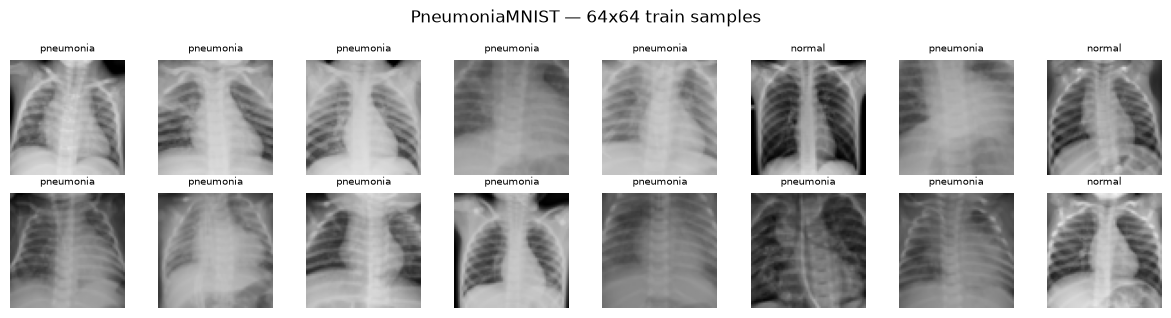

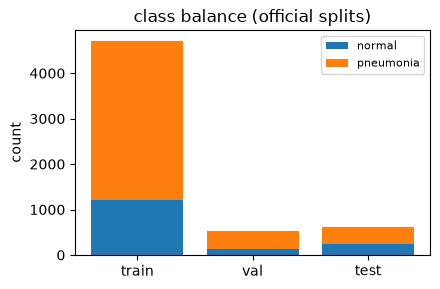

BCE pos_weight (imbalance handling, identical for every arm): tensor([0.3475])


In [7]:
RAW = load_pneumoniamnist(CFG)
DS = build_datasets(RAW, CFG, smoke=SMOKE)

print("\ndataset sizes used in this run:",
      {k: len(v) for k, v in DS.items() if isinstance(v, Dataset)})

# --- I3 assertion: labels are unreachable inside a pretraining loop -------------
_leaked = True
with label_blind():
    try:
        _ = DS["train_aug"][0]
    except LabelLeakageError:
        _leaked = False
assert not _leaked, "I3 FAILED: labeled dataset was readable inside label_blind()"
assert not hasattr(DS["pretrain"], "labels"), "I3 FAILED: pretrain view carries labels"
_ = DS["train_aug"][0]  # outside the guard it works again
print("[I3] label-leakage guard OK: labeled access raises during pretraining, works outside it.")

# --- sample grid -----------------------------------------------------------------
xb = torch.stack([DS["pretrain"][i] for i in range(16)])
print("pretrain batch:", tuple(xb.shape), "range", (float(xb.min()), float(xb.max())))

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
tr_raw = DS["_raw"]["train"]
for i, ax in enumerate(axes.ravel()):
    ax.imshow(tr_raw["images"][i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title("pneumonia" if tr_raw["labels"][i] == 1 else "normal", fontsize=7)
    ax.axis("off")
fig.suptitle(f"PneumoniaMNIST — {CFG.data.size}x{CFG.data.size} train samples")
fig.tight_layout()
fig.savefig(FIG_DIR / "m0_samples.png", dpi=130)
plt.show()

# class balance bar
fig, ax = plt.subplots(figsize=(4.5, 3))
splits = ["train", "val", "test"]
n0 = [int((RAW[s]["labels"] == 0).sum()) for s in splits]
n1 = [int((RAW[s]["labels"] == 1).sum()) for s in splits]
ax.bar(splits, n0, label="normal")
ax.bar(splits, n1, bottom=n0, label="pneumonia")
ax.set_ylabel("count")
ax.set_title("class balance (official splits)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "m0_class_balance.png", dpi=130)
plt.show()

POS_WEIGHT = pos_weight_from(DS["_raw"]["train"]["labels"], CFG)
print("BCE pos_weight (imbalance handling, identical for every arm):", POS_WEIGHT)

## Setup 5 — the shared encoder (`backbone.py`)

**I1: this is the only encoder in the notebook.** Every arm calls `build_encoder(CFG)` —
same class, same config, same parameter shapes. The trunk is a small conv U-Net encoder:

```
stem 1->32 @64x64
  stage0  32ch @64  ->  down
  stage1  64ch @32  ->  down
  stage2 128ch @16  ->  down
  stage3 256ch @8
  mid1   256ch @8      <- selectable extraction point
  mid2   256ch @8      <- "bottleneck" (default extraction point, I2)
```

The trunk always carries a **sinusoidal timestep embedding → MLP**, injected into every
residual block as FiLM (per-channel scale/shift). The diffusion arm passes real `t`;
every other arm passes `t=0`. The embedding path is part of the trunk for *all* arms, which
is what keeps the parameter counts byte-for-byte identical.

`extract(x, t, block, pooler)` is the single feature-extraction site (I2): one forward pass,
pooled feature `[B, C]`. Global average pooling is the default; `AttnPool` is available
(the paper found self-attention pooling best) but lives **outside** the encoder so it cannot
perturb parameter parity — it is part of the probe head, applied identically to every arm.

In [8]:
def timestep_embedding(t, dim, max_period=10000.0):
    """Sinusoidal embedding, as in DDPM/Transformer."""
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(half, dtype=torch.float32, device=t.device) / half
    )
    args = t.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        emb = F.pad(emb, (0, 1))
    return emb


def _gn(groups, ch):
    g = math.gcd(groups, ch)
    return nn.GroupNorm(max(1, g), ch)


class ResBlock(nn.Module):
    """GroupNorm -> SiLU -> conv, with FiLM timestep conditioning."""

    def __init__(self, in_ch, out_ch, emb_dim, groups=8, dropout=0.0):
        super().__init__()
        self.norm1 = _gn(groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, 2 * out_ch)     # -> (scale, shift)
        self.norm2 = _gn(groups, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.emb_proj(F.silu(emb)).chunk(2, dim=-1)
        h = self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(h)))
        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Encoder(nn.Module):
    """THE shared trunk (I1). Identical class + config for every arm."""

    def __init__(self, in_ch=1, base=32, ch_mults=(1, 2, 4, 8), blocks_per_stage=1,
                 n_mid=2, emb_dim=128, groups=8, dropout=0.0):
        super().__init__()
        self.in_ch, self.base, self.ch_mults = in_ch, base, tuple(ch_mults)
        self.emb_dim, self.n_mid = emb_dim, n_mid

        self.time_mlp = nn.Sequential(
            nn.Linear(base, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim)
        )
        self.stem = nn.Conv2d(in_ch, base, 3, padding=1)

        chs = [base * m for m in self.ch_mults]
        self.stage_blocks = nn.ModuleList()
        self.downs = nn.ModuleList()
        cur = base
        for i, out_ch in enumerate(chs):
            blocks = nn.ModuleList(
                [ResBlock(cur if b == 0 else out_ch, out_ch, emb_dim, groups, dropout)
                 for b in range(blocks_per_stage)]
            )
            self.stage_blocks.append(blocks)
            cur = out_ch
            if i < len(chs) - 1:
                self.downs.append(Downsample(cur))

        self.mids = nn.ModuleList(
            [ResBlock(cur, cur, emb_dim, groups, dropout) for _ in range(n_mid)]
        )
        self.channels = chs
        self.out_ch = cur

    # ---- feature-site bookkeeping -------------------------------------------------
    @property
    def blocks_available(self):
        names = [f"stage{i}" for i in range(len(self.channels))]
        names += [f"mid{j + 1}" for j in range(self.n_mid)]
        return names + ["bottleneck"]

    def feature_dim(self, block="bottleneck"):
        if block.startswith("stage"):
            return self.channels[int(block[5:])]
        return self.out_ch

    def _emb(self, x, t):
        B = x.shape[0]
        if not torch.is_tensor(t):
            t = torch.full((B,), float(t), device=x.device)
        t = t.to(x.device).float().reshape(-1)
        if t.numel() == 1 and B > 1:
            t = t.expand(B)
        return self.time_mlp(timestep_embedding(t, self.base))

    def forward_features(self, x, t=0):
        """Returns (h, skips, emb, feats) -- skips feed the arm decoders."""
        emb = self._emb(x, t)
        h = self.stem(x)
        skips, feats = [], {}
        n = len(self.stage_blocks)
        for i, blocks in enumerate(self.stage_blocks):
            for blk in blocks:
                h = blk(h, emb)
            feats[f"stage{i}"] = h
            if i < n - 1:
                skips.append(h)
                h = self.downs[i](h)
        for j, mid in enumerate(self.mids):
            h = mid(h, emb)
            feats[f"mid{j + 1}"] = h
        feats["bottleneck"] = h
        return h, skips, emb, feats

    def forward(self, x, t=0):
        return self.forward_features(x, t)[0]

    def extract(self, x, t=0, block="bottleneck", pooler=None):
        """I2: THE feature-extraction path. Same code for every arm; only `t` varies."""
        _, _, _, feats = self.forward_features(x, t)
        h = feats[block]
        if pooler is not None:
            return pooler(h)
        return h.mean(dim=(2, 3))                      # global average pool -> [B, C]


class AttnPool(nn.Module):
    """Optional self-attention pooling. Probe-side, NOT part of the encoder (keeps I1 safe)."""

    def __init__(self, dim, heads=4):
        super().__init__()
        self.q = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, h):
        B, C, H, W = h.shape
        tok = self.norm(h.flatten(2).transpose(1, 2))          # [B, HW, C]
        out, _ = self.attn(self.q.expand(B, -1, -1), tok, tok)
        return out[:, 0]


class Decoder(nn.Module):
    """Lightweight conv decoder shared in *shape* by the arms (each arm owns its own copy).

    Not part of the encoder, so it never enters the parity check.
    """

    def __init__(self, base=32, ch_mults=(1, 2, 4, 8), emb_dim=128, out_ch=1,
                 groups=8, use_skips=True, dropout=0.0):
        super().__init__()
        chs = [base * m for m in ch_mults]
        self.use_skips = use_skips
        self.blocks = nn.ModuleList()
        cur = chs[-1]
        for i in reversed(range(len(chs) - 1)):
            in_ch = cur + (chs[i] if use_skips else 0)
            self.blocks.append(ResBlock(in_ch, chs[i], emb_dim, groups, dropout))
            cur = chs[i]
        self.out_norm = _gn(groups, cur)
        self.out_conv = nn.Conv2d(cur, out_ch, 3, padding=1)
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

    def forward(self, h, skips, emb):
        skips = list(skips)
        for blk in self.blocks:
            h = F.interpolate(h, scale_factor=2.0, mode="nearest")
            s = skips.pop() if skips else None
            if self.use_skips and s is not None:
                h = torch.cat([h, s], dim=1)
            h = blk(h, emb)
        return self.out_conv(F.silu(self.out_norm(h)))


def build_encoder(cfg):
    """The ONE constructor every arm must use (I1)."""
    e = cfg.encoder
    return Encoder(
        in_ch=cfg.data.in_channels, base=e.base, ch_mults=e.ch_mults,
        blocks_per_stage=e.blocks_per_stage, n_mid=e.n_mid, emb_dim=e.emb_dim,
        groups=e.groups, dropout=e.dropout,
    )


def build_decoder(cfg, use_skips):
    e = cfg.encoder
    return Decoder(base=e.base, ch_mults=e.ch_mults, emb_dim=e.emb_dim,
                   out_ch=cfg.data.in_channels, groups=e.groups,
                   use_skips=use_skips, dropout=e.dropout)


def build_pooler(cfg, encoder, block=None, seed=0):
    """GAP (default, parameter-free) or AttnPool. Same choice for every arm (I5)."""
    if cfg.encoder.pool == "gap":
        return None
    torch.manual_seed(seed)
    return AttnPool(encoder.feature_dim(block or cfg.encoder.default_block))

# M1 — encoder parity assertions

Builds the encoder that each arm would use and asserts that the parameter **count** and the
full `(name, shape)` **signature** are identical. If a future edit gives one arm a different
trunk, this cell fails loudly instead of producing a quietly confounded comparison.

In [9]:
def assert_param_parity(encoders, verbose=True):
    """I1: every arm's encoder must be the same class with the same parameter shapes."""
    names = list(encoders.keys())
    ref_name = names[0]
    ref = encoders[ref_name]
    ref_n, ref_sig = count_params(ref), param_signature(ref)
    for nm in names[1:]:
        enc = encoders[nm]
        assert type(enc) is type(ref), f"I1 FAILED: {nm} uses {type(enc)} != {type(ref)}"
        n = count_params(enc)
        assert n == ref_n, f"I1 FAILED: {nm} has {n} encoder params, {ref_name} has {ref_n}"
        assert param_signature(enc) == ref_sig, f"I1 FAILED: {nm} parameter shapes differ"
    if verbose:
        print(f"[I1] encoder parity OK across {names}: {ref_n:,} params each")
    return ref_n


_probe_enc = build_encoder(CFG)
print(_probe_enc)
print("\nencoder blocks available for extraction (I2 sites):", _probe_enc.blocks_available)
print("feature dims:", {b: _probe_enc.feature_dim(b) for b in _probe_enc.blocks_available})

# shape / timestep smoke test
_x = torch.randn(2, CFG.data.in_channels, CFG.data.size, CFG.data.size)
for _t in (0, 250):
    _h, _sk, _emb, _f = _probe_enc.forward_features(_x, _t)
    print(f"t={_t:4d}  bottleneck {tuple(_h.shape)}  skips {[tuple(s.shape) for s in _sk]}"
          f"  emb {tuple(_emb.shape)}")
_feat = _probe_enc.extract(_x, t=0)
print("extract() ->", tuple(_feat.shape))

ENCODER_PARAMS = assert_param_parity({
    "diffusion": build_encoder(CFG),
    "mae": build_encoder(CFG),
    "jepa": build_encoder(CFG),
    "supervised": build_encoder(CFG),
})
_dec_d = build_decoder(CFG, CFG.diffusion.decoder_skips)
_dec_m = build_decoder(CFG, CFG.mae.decoder_skips)
print(f"arm-specific decoders (outside the parity check): "
      f"diffusion {count_params(_dec_d):,} | mae {count_params(_dec_m):,}")
del _probe_enc, _x, _h, _sk, _emb, _f, _feat, _dec_d, _dec_m

Encoder(
  (time_mlp): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (stem): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (stage_blocks): ModuleList(
    (0): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (emb_proj): Linear(in_features=128, out_features=64, bias=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (skip): Identity()
      )
    )
    (1): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
        (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (emb_pr

## Setup 6 — the arms (`arms/diffusion.py`, `arms/mae.py`, `arms/jepa.py`)

Every arm is `nn.Module` with the same tiny interface:

* `self.encoder` — **the** shared trunk (built by `build_encoder(CFG)`, never anything else);
* `loss(x) -> scalar` — the objective, given a batch of shared-pipeline images;
* `post_step()` — optional hook (JEPA's EMA update).

That interface is what lets `pretrain_arm()` give every arm literally the same optimizer,
schedule and step count (I4).

### Diffusion (the OrthoDiffusion mechanism)
Standard DDPM: cosine schedule, `T=1000`, ε-prediction, ℓ2 loss. The denoiser **is** the
shared trunk plus a light conv decoder; the trunk's timestep embedding is finally used for
real here. Sampling uses a strided DDIM(η=1) sampler so a sanity-check grid takes seconds.

### MAE / SimMIM
Convolutional SimMIM: mask a fraction of `patch_size × patch_size` input patches, replace
them with a learnable mask token (owned by the arm, *not* the encoder), run the shared trunk,
reconstruct with a light conv decoder, ℓ2 **on masked pixels only**.

> **Known, deliberate asymmetry (flagged rather than hidden):** the diffusion decoder keeps
> the standard U-Net skip connections (`diffusion.decoder_skips: true`) while the MAE decoder
> does not (`mae.decoder_skips: false`), because SimMIM's whole point is to force information
> through the bottleneck. Skips let a denoiser route detail *around* the bottleneck, which
> can weaken the very feature site we probe. Both are config flags — flip either one to
> measure the effect.

In [10]:
# ------------------------------------------------------------------ diffusion
class GaussianDiffusion:
    """DDPM schedule + q_sample + ε-loss + DDIM(η) sampler. No learnable state."""

    def __init__(self, T=1000, schedule="cosine", device="cpu"):
        self.T, self.schedule = int(T), schedule
        if schedule == "cosine":
            s = 0.008
            steps = torch.arange(self.T + 1, dtype=torch.float64) / self.T
            f = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
            abar = (f / f[0]).clamp(1e-8, 1.0)
            betas = (1 - abar[1:] / abar[:-1]).clamp(1e-8, 0.999)
        elif schedule == "linear":
            betas = torch.linspace(1e-4, 0.02, self.T, dtype=torch.float64)
        else:
            raise ValueError(schedule)
        alphas = 1.0 - betas
        self.betas = betas.float().to(device)
        # clamp keeps the sampler's 1/sqrt(abar_t) finite at t -> T (matters for `linear`)
        self.alphas_bar = torch.cumprod(alphas, dim=0).clamp_min(1e-8).float().to(device)
        self.sqrt_ab = self.alphas_bar.sqrt()
        self.sqrt_1mab = (1 - self.alphas_bar).sqrt()
        self.device = device

    def to(self, device):
        for k in ("betas", "alphas_bar", "sqrt_ab", "sqrt_1mab"):
            setattr(self, k, getattr(self, k).to(device))
        self.device = device
        return self

    def q_sample(self, x0, t, noise):
        """x_t = sqrt(abar_t) x0 + sqrt(1-abar_t) eps  -- the ONLY corruption used at extraction."""
        t = t.to(self.sqrt_ab.device).long()
        a = self.sqrt_ab[t].view(-1, *([1] * (x0.dim() - 1)))
        b = self.sqrt_1mab[t].view(-1, *([1] * (x0.dim() - 1)))
        return a * x0 + b * noise

    def eps_loss(self, model, x0):
        B = x0.shape[0]
        t = torch.randint(0, self.T, (B,), device=x0.device)
        noise = torch.randn_like(x0)
        x_t = self.q_sample(x0, t, noise)
        eps_hat = model(x_t, t)
        return F.mse_loss(eps_hat, noise)

    @torch.no_grad()
    def sample(self, model, n, shape, steps=None, eta=1.0, device=None, seed=None):
        device = device or self.device
        steps = int(steps or self.T)
        if seed is not None:
            torch.manual_seed(seed)
        seq = torch.linspace(self.T - 1, 0, steps).round().long().tolist()
        x = torch.randn(n, *shape, device=device)
        for i, t in enumerate(seq):
            t_prev = seq[i + 1] if i + 1 < len(seq) else -1
            tt = torch.full((n,), t, device=device, dtype=torch.long)
            eps = model(x, tt)
            ab_t = self.alphas_bar[t]
            ab_prev = self.alphas_bar[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=device)
            x0 = ((x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()).clamp(-1, 1)
            sigma = eta * ((1 - ab_prev) / (1 - ab_t)).sqrt() * (1 - ab_t / ab_prev).sqrt()
            sigma = torch.nan_to_num(sigma, nan=0.0)
            dir_xt = (1 - ab_prev - sigma ** 2).clamp(min=0).sqrt() * eps
            x = ab_prev.sqrt() * x0 + dir_xt
            if t_prev >= 0:
                x = x + sigma * torch.randn_like(x)
        return x.clamp(-1, 1)


class DiffusionArm(nn.Module):
    """DDPM whose denoiser trunk IS the shared encoder (I1)."""

    name = "diffusion"

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.encoder = build_encoder(cfg)                       # <- the shared trunk
        self.decoder = build_decoder(cfg, cfg.diffusion.decoder_skips)
        self.diffusion = GaussianDiffusion(cfg.diffusion.T, cfg.diffusion.schedule)

    def forward(self, x_t, t):
        h, skips, emb, _ = self.encoder.forward_features(x_t, t)
        return self.decoder(h, skips, emb)                      # predicts eps

    def loss(self, x):
        return self.diffusion.eps_loss(self, x)


# ------------------------------------------------------------------------ MAE
def random_patch_mask(B, H, W, patch, ratio, device):
    """1 = masked. Whole patches, per-sample random, exactly round(ratio*n) patches."""
    h, w = H // patch, W // patch
    n = h * w
    k = max(1, int(round(ratio * n)))
    idx = torch.rand(B, n, device=device).argsort(dim=1)
    mask = torch.zeros(B, n, device=device)
    mask.scatter_(1, idx[:, :k], 1.0)
    mask = mask.view(B, 1, h, w)
    return F.interpolate(mask, scale_factor=patch, mode="nearest")


class MAEArm(nn.Module):
    """SimMIM-style masked reconstruction on the shared trunk."""

    name = "mae"

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.encoder = build_encoder(cfg)                       # <- the shared trunk
        self.decoder = build_decoder(cfg, cfg.mae.decoder_skips)
        # mask token belongs to the ARM, not the encoder -> parity (I1) is untouched
        self.mask_token = nn.Parameter(torch.zeros(1, cfg.data.in_channels, 1, 1))

    def mask_and_reconstruct(self, x, mask=None):
        B, C, H, W = x.shape
        if mask is None:
            mask = random_patch_mask(B, H, W, self.cfg.mae.patch_size,
                                     self.cfg.mae.mask_ratio, x.device)
        x_masked = x * (1 - mask) + self.mask_token * mask
        h, skips, emb, _ = self.encoder.forward_features(x_masked, 0)
        rec = self.decoder(h, skips, emb)
        return rec, mask, x_masked

    def loss(self, x):
        rec, mask, _ = self.mask_and_reconstruct(x)
        # l2 on masked pixels only
        return ((rec - x) ** 2 * mask).sum() / (mask.sum() * x.shape[1] + 1e-8)


# ----------------------------------------------------------------------- JEPA
class JEPAArm(nn.Module):
    """I-JEPA-lite: predict the TARGET encoder's bottleneck latents from a masked context.

    Phase 2 -- fully implemented, but gated behind `jepa.enabled` in the config so the
    headline comparison stays the two arms the study is about.
    """

    name = "jepa"

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.encoder = build_encoder(cfg)                       # context encoder (shared trunk)
        self.target_encoder = build_encoder(cfg)                # same class+config (I1)
        self.target_encoder.load_state_dict(self.encoder.state_dict())
        for p in self.target_encoder.parameters():
            p.requires_grad_(False)
        c = self.encoder.out_ch
        hid = cfg.jepa.pred_hidden
        self.predictor = nn.Sequential(
            nn.Conv2d(c, hid, 3, padding=1), nn.GroupNorm(math.gcd(8, hid), hid), nn.SiLU(),
            nn.Conv2d(hid, c, 3, padding=1),
        )
        self.mask_token = nn.Parameter(torch.zeros(1, cfg.data.in_channels, 1, 1))

    def loss(self, x):
        B, C, H, W = x.shape
        mask = random_patch_mask(B, H, W, self.cfg.jepa.patch_size,
                                 self.cfg.jepa.mask_ratio, x.device)
        ctx = x * (1 - mask) + self.mask_token * mask
        z_ctx = self.encoder(ctx, 0)
        with torch.no_grad():
            z_tgt = self.target_encoder(x, 0)
        z_tgt = F.layer_norm(z_tgt, z_tgt.shape[-3:])           # anti-collapse normalization
        pred = self.predictor(z_ctx)
        pred = F.layer_norm(pred, pred.shape[-3:])
        return F.smooth_l1_loss(pred, z_tgt.detach())

    @torch.no_grad()
    def post_step(self):
        m = self.cfg.jepa.ema
        for pt, ps in zip(self.target_encoder.parameters(), self.encoder.parameters()):
            pt.mul_(m).add_(ps.detach(), alpha=1 - m)
        for bt, bs in zip(self.target_encoder.buffers(), self.encoder.buffers()):
            bt.copy_(bs)


ARMS = {"diffusion": DiffusionArm, "mae": MAEArm, "jepa": JEPAArm}


def build_arm(name, cfg):
    return ARMS[name](cfg)

## Setup 7 — the pretraining driver (`scripts/train_pretrain.py`)

**I4 lives here.** One function trains any arm: same optimizer family (AdamW), same LR,
same warmup + cosine schedule, same gradient clipping, and the **same number of optimizer
steps** — all read from the single `pretrain:` config block, with no per-arm branch. Wall
clock and step count are recorded and end up in the results CSV.

The whole loop runs inside `label_blind()`, so any accidental label read raises (I3).
Checkpoints land in `checkpoints/{arm}_seed{k}.pt`; re-running the cell reloads instead of
retraining unless you pass `force=True`.

In [11]:
try:
    from tqdm.auto import tqdm
except Exception:                                              # tqdm is optional
    def tqdm(x=None, **kw):
        return x if x is not None else None


def infinite(loader):
    while True:
        for batch in loader:
            yield batch


def pretrain_arm(arm_name, seed, cfg, datasets, device=DEVICE, force=False, verbose=True):
    """Train one arm for cfg.pretrain.steps steps. Returns dict(encoder=..., meta=...)."""
    ckpt_path = CKPT_DIR / f"{arm_name}_seed{seed}.pt"
    if ckpt_path.exists() and not force:
        try:
            blob = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        except TypeError:                                      # torch < 2.0
            blob = torch.load(ckpt_path, map_location="cpu")
        if blob.get("steps") == cfg.pretrain.steps:
            model = build_arm(arm_name, cfg)
            model.load_state_dict(blob["model"])
            model.to(device).eval()
            if verbose:
                print(f"[{arm_name} seed={seed}] loaded checkpoint "
                      f"({blob['steps']} steps, {fmt_time(blob['wall_s'])})")
            return {"arm": arm_name, "seed": seed, "model": model,
                    "encoder": model.encoder, **{k: blob[k] for k in ("steps", "wall_s", "loss_hist")}}

    set_seed(seed)
    model = build_arm(arm_name, cfg).to(device)
    if hasattr(model, "diffusion"):
        model.diffusion.to(device)

    steps = int(cfg.pretrain.steps)
    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.pretrain.lr, weight_decay=cfg.pretrain.weight_decay,
        betas=tuple(cfg.pretrain.betas),
    )
    loader = DataLoader(datasets["pretrain"], batch_size=cfg.data.batch_size, shuffle=True,
                        drop_last=True, num_workers=cfg.data.num_workers)
    it = infinite(loader)

    loss_hist, running, t0 = [], [], time.time()
    model.train()
    pbar = tqdm(range(steps), desc=f"pretrain {arm_name} seed={seed}")
    with label_blind():                                        # I3
        for step in pbar if pbar is not None else range(steps):
            x = next(it).to(device)
            lr = cosine_lr(step, steps, cfg.pretrain.lr, cfg.pretrain.warmup_steps)
            for g in opt.param_groups:
                g["lr"] = lr
            loss = model.loss(x)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.pretrain.grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.pretrain.grad_clip)
            opt.step()
            if hasattr(model, "post_step"):
                model.post_step()
            running.append(float(loss.detach().cpu()))
            if (step + 1) % cfg.pretrain.log_every == 0 or step == steps - 1:
                m = sum(running) / len(running)
                loss_hist.append((step + 1, m))
                if verbose:
                    print(f"  [{arm_name} seed={seed}] step {step + 1}/{steps} "
                          f"loss={m:.4f} lr={lr:.2e} elapsed={fmt_time(time.time() - t0)}")
                running = []
    wall = time.time() - t0
    model.eval()
    torch.save({"model": model.state_dict(), "steps": steps, "wall_s": wall,
                "loss_hist": loss_hist, "cfg": dict(cfg), "seed": seed}, ckpt_path)
    if verbose:
        print(f"[{arm_name} seed={seed}] done in {fmt_time(wall)} -> {ckpt_path}")
    return {"arm": arm_name, "seed": seed, "model": model, "encoder": model.encoder,
            "steps": steps, "wall_s": wall, "loss_hist": loss_hist}


def plot_loss_curves(results, title, path):
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    for r in results:
        if r["loss_hist"]:
            xs, ys = zip(*r["loss_hist"])
            ax.plot(xs, ys, marker="o", ms=3, label=f"seed {r['seed']}")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.show()


def show_grid(imgs, title, path, nrow=8, vmin=-1, vmax=1):
    imgs = imgs.detach().cpu()
    n = imgs.shape[0]
    ncol = min(nrow, n)
    nrows = int(math.ceil(n / ncol))
    fig, axes = plt.subplots(nrows, ncol, figsize=(1.5 * ncol, 1.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(imgs[i, 0].numpy(), cmap="gray", vmin=vmin, vmax=vmax)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.show()

# M2 — diffusion arm: train the DDPM, then sample to prove it learned the manifold

The samples will not be beautiful at this budget — what we need to see is chest-shaped
structure (lung fields, rib cage, mediastinum) rather than noise or a constant blob. If the
grid is pure noise, the arm did not train and everything downstream is meaningless.

[diffusion seed=0] loaded checkpoint (4000 steps, 43m07s)
[diffusion seed=1] loaded checkpoint (4000 steps, 34m49s)
[diffusion seed=2] loaded checkpoint (4000 steps, 37m30s)


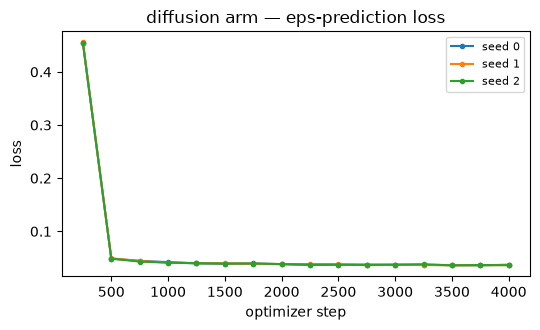

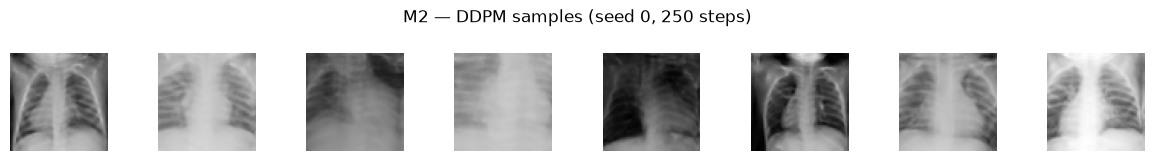

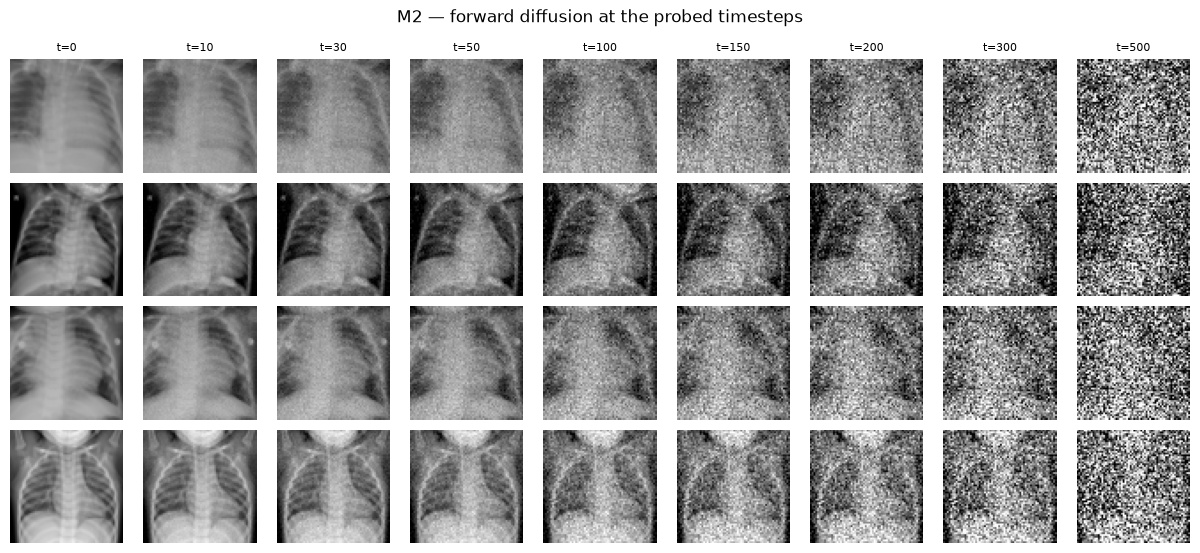

In [12]:
DIFF_RUNS = [pretrain_arm("diffusion", s, CFG, DS) for s in CFG.eval.seeds]
plot_loss_curves(DIFF_RUNS, "diffusion arm — eps-prediction loss", FIG_DIR / "m2_diffusion_loss.png")

_r = DIFF_RUNS[0]
_samples = _r["model"].diffusion.to(DEVICE).sample(
    _r["model"], n=CFG.diffusion.sample_n,
    shape=(CFG.data.in_channels, CFG.data.size, CFG.data.size),
    steps=CFG.diffusion.sample_steps, eta=CFG.diffusion.sample_eta,
    device=DEVICE, seed=0,
)
show_grid(_samples, f"M2 — DDPM samples (seed {_r['seed']}, {CFG.diffusion.sample_steps} steps)",
          FIG_DIR / "m2_diffusion_samples.png")

# also show the forward process at the timesteps we will probe, so the ablation is readable
_x0 = torch.stack([DS["val"][i][0] for i in range(4)]).to(DEVICE)
_ts = [0] + list(CFG.ablation.timesteps)
fig, axes = plt.subplots(4, len(_ts), figsize=(1.35 * len(_ts), 5.6))
torch.manual_seed(0)
_noise = torch.randn_like(_x0)
for j, t in enumerate(_ts):
    xt = _x0 if t == 0 else _r["model"].diffusion.q_sample(
        _x0, torch.full((_x0.shape[0],), t, device=DEVICE, dtype=torch.long), _noise)
    for i in range(4):
        axes[i, j].imshow(xt[i, 0].detach().cpu().numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[i, j].axis("off")
    axes[0, j].set_title(f"t={t}", fontsize=8)
fig.suptitle("M2 — forward diffusion at the probed timesteps")
fig.tight_layout()
fig.savefig(FIG_DIR / "m2_forward_process.png", dpi=130)
plt.show()
del _samples, _x0, _noise

# M3 — MAE arm: train, then visualize reconstructions

Rows: original / masked input / reconstruction / reconstruction pasted onto the visible
pixels. If the reconstruction is a flat gray field, the arm collapsed.

[mae seed=0] loaded checkpoint (4000 steps, 34m06s)
[mae seed=1] loaded checkpoint (4000 steps, 37m42s)
[mae seed=2] loaded checkpoint (4000 steps, 41m29s)


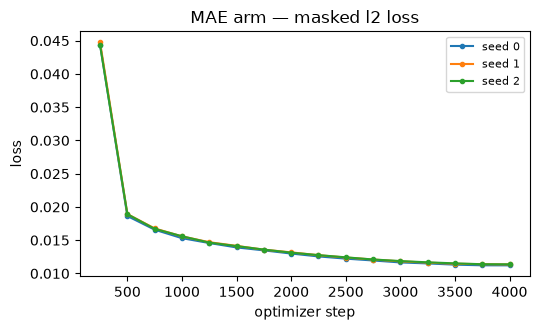

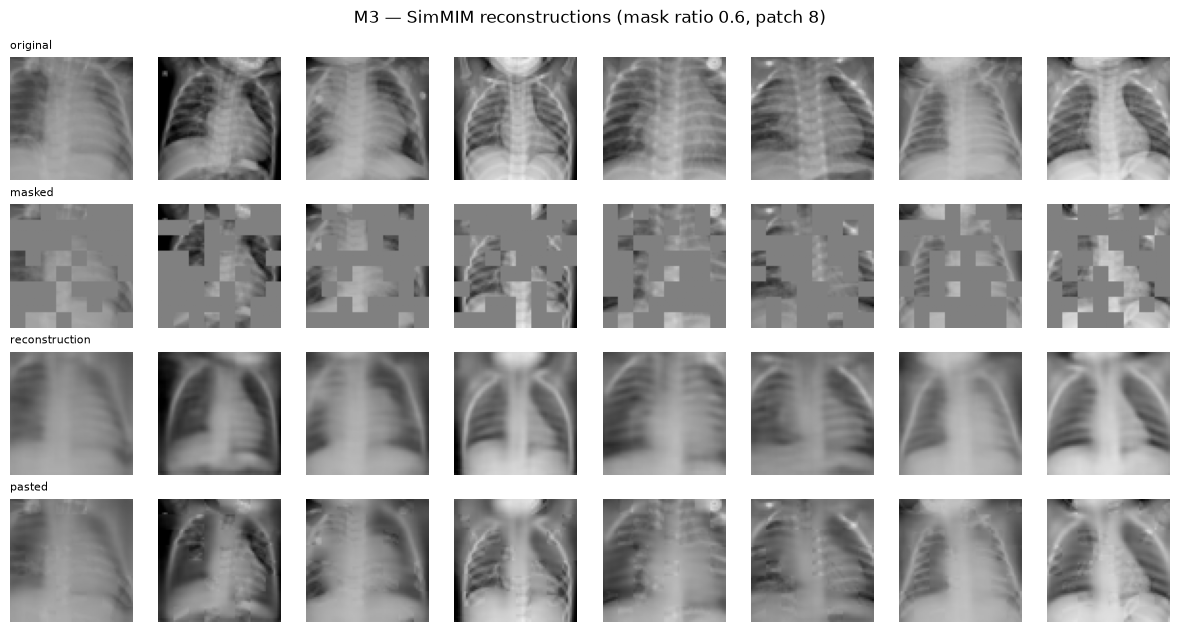

In [13]:
MAE_RUNS = [pretrain_arm("mae", s, CFG, DS) for s in CFG.eval.seeds]
plot_loss_curves(MAE_RUNS, "MAE arm — masked l2 loss", FIG_DIR / "m3_mae_loss.png")

_m = MAE_RUNS[0]["model"]
_x = torch.stack([DS["val"][i][0] for i in range(8)]).to(DEVICE)
torch.manual_seed(0)
with torch.no_grad():
    _rec, _mask, _xm = _m.mask_and_reconstruct(_x)
_paste = _x * (1 - _mask) + _rec * _mask

fig, axes = plt.subplots(4, 8, figsize=(12, 6.4))
for i in range(8):
    for r, (img, lab) in enumerate([(_x, "original"), (_xm, "masked"),
                                    (_rec, "reconstruction"), (_paste, "pasted")]):
        axes[r, i].imshow(img[i, 0].detach().cpu().numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[r, i].axis("off")
        if i == 0:
            axes[r, i].set_ylabel(lab)
            axes[r, i].set_title(lab, fontsize=8, loc="left")
fig.suptitle(f"M3 — SimMIM reconstructions (mask ratio {CFG.mae.mask_ratio}, "
             f"patch {CFG.mae.patch_size})")
fig.tight_layout()
fig.savefig(FIG_DIR / "m3_mae_reconstructions.png", dpi=130)
plt.show()
del _x, _rec, _mask, _xm, _paste

## Setup 8 — feature extraction (`features.py`)

**I2 in one function.** Every arm's downstream feature comes from here: one forward pass
through the shared trunk, read the named block, pool. The *only* thing that differs between
arms is the timestep `t`:

* MAE / JEPA / supervised / random → `t = 0`, clean input (the "t=0 analog");
* diffusion → `x_t = sqrt(abar_t)·x0 + sqrt(1-abar_t)·eps`, and `t` is also fed to the trunk's
  timestep embedding.

The noise is drawn from a **fixed CPU generator** (`eval.feature_noise_seed`), so the same
image gets the same corruption in every arm, every seed and every sweep point — the ablation
curve measures the representation, not noise luck.

In [14]:
def apply_t(x, t, diffusion, generator=None):
    """Corrupt a clean batch to timestep t (no-op at t=0). Shared by probe and finetune."""
    if not t:
        return x
    noise = torch.randn(x.shape, generator=generator, dtype=torch.float32)
    noise = noise.to(x.device)
    tt = torch.full((x.shape[0],), int(t), device=x.device, dtype=torch.long)
    return diffusion.q_sample(x, tt, noise)


@torch.no_grad()
def extract_features(encoder, images, cfg, t=0, block=None, diffusion=None, pooler=None,
                     device=DEVICE, noise_seed=None):
    """THE feature-extraction site (I2). images: clean normalized [N,1,S,S] on CPU."""
    encoder.eval().to(device)
    block = block or cfg.encoder.default_block
    if t:
        assert diffusion is not None, "t>0 requires the diffusion schedule"
        diffusion.to(device)
    gen = torch.Generator().manual_seed(int(noise_seed if noise_seed is not None
                                            else cfg.eval.feature_noise_seed))
    out = []
    bs = int(cfg.data.eval_batch_size)
    for i in range(0, images.shape[0], bs):
        x = images[i:i + bs].to(device)
        x = apply_t(x, t, diffusion, generator=gen)
        f = encoder.extract(x, t=t, block=block, pooler=pooler)
        out.append(f.float().cpu())
    return torch.cat(out, dim=0)


FEATURE_CACHE = {}


def features_for(run, cfg, t=0, block=None, splits=("train", "val", "test"), use_cache=True):
    """Extract (and cache) features for one pretrained run at one (t, block)."""
    block = block or cfg.encoder.default_block
    diffusion = getattr(run["model"], "diffusion", None) if run.get("model") is not None else None
    if diffusion is None and t:
        diffusion = GaussianDiffusion(cfg.diffusion.T, cfg.diffusion.schedule, DEVICE)
    pooler = build_pooler(cfg, run["encoder"], block, seed=run["seed"])
    if pooler is not None:
        pooler.to(DEVICE).eval()
    feats, labels = {}, {}
    for sp in splits:
        key = (run["arm"], run["seed"], int(t), block, sp, cfg.encoder.pool)
        if use_cache and key in FEATURE_CACHE:
            feats[sp] = FEATURE_CACHE[key]
        else:
            imgs = eval_tensor(DS["_raw"][sp if sp != "train" else "train"], cfg)
            f = extract_features(run["encoder"], imgs, cfg, t=t, block=block,
                                 diffusion=diffusion, pooler=pooler)
            FEATURE_CACHE[key] = f
            feats[sp] = f
        labels[sp] = DS["_raw"][sp]["labels"]
    return feats, labels

## Setup 9 — linear probe & fine-tune (`probe.py`)

**I5 in two functions.** Both recipes come from the `probe:` / `finetune:` config blocks and
take no per-arm arguments — there is nowhere to hand-tune one arm's hyperparameters.
Both use class-weighted `BCEWithLogitsLoss` (the imbalance handling), select the best epoch
by **validation** AUROC, and only then touch the test split once (I6).

In [15]:
class LinearHead(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Linear(dim, 1)
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, f):
        return self.fc(f).squeeze(-1)


def _bce(pos_weight, device):
    pw = None if pos_weight is None else pos_weight.to(device)
    return nn.BCEWithLogitsLoss(pos_weight=pw)


def linear_probe(feats, labels, cfg, seed, device=DEVICE, verbose=False):
    """Frozen features -> single nn.Linear. Identical recipe for every arm (I5)."""
    set_seed(seed)
    Xtr = feats["train"].to(device)
    if cfg.probe.standardize:
        mu, sd = Xtr.mean(0, keepdim=True), Xtr.std(0, keepdim=True).clamp_min(1e-6)
    else:
        mu = torch.zeros(1, Xtr.shape[1], device=device)
        sd = torch.ones(1, Xtr.shape[1], device=device)
    X = {sp: ((feats[sp].to(device) - mu) / sd) for sp in feats}
    Y = {sp: torch.tensor(labels[sp], dtype=torch.float32, device=device) for sp in labels}

    head = LinearHead(X["train"].shape[1]).to(device)
    opt = torch.optim.AdamW(head.parameters(), lr=cfg.probe.lr,
                            weight_decay=cfg.probe.weight_decay)
    crit = _bce(pos_weight_from(labels["train"], cfg), device)
    n = X["train"].shape[0]
    bs = int(cfg.probe.batch_size)

    best = {"auroc": -1.0}
    best_state, hist = None, []
    for ep in range(int(cfg.probe.epochs)):
        head.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            loss = crit(head(X["train"][idx]), Y["train"][idx])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        head.eval()
        with torch.no_grad():
            p = torch.sigmoid(head(X["val"])).cpu().numpy()
        m = binary_metrics(labels["val"], p)                    # selection on VAL only (I6)
        hist.append(m["auroc"])
        if m["auroc"] > best["auroc"]:
            best = m
            best_state = copy.deepcopy(head.state_dict())
        if verbose and (ep + 1) % 10 == 0:
            print(f"    probe ep{ep + 1:3d} val {fmt_metrics(m)}")
    head.load_state_dict(best_state)
    head.eval()
    with torch.no_grad():
        p_test = torch.sigmoid(head(X["test"])).cpu().numpy()
    test_m = binary_metrics(labels["test"], p_test)             # test touched ONCE
    return {"val": best, "test": test_m, "history": hist}


class ProbeModel(nn.Module):
    """encoder (I2 extraction path) + linear head, for end-to-end fine-tuning."""

    def __init__(self, encoder, cfg, block=None, pooler=None):
        super().__init__()
        self.encoder = encoder
        self.block = block or cfg.encoder.default_block
        self.pooler = pooler
        self.head = LinearHead(encoder.feature_dim(self.block))

    def forward(self, x, t=0):
        return self.head(self.encoder.extract(x, t=t, block=self.block, pooler=self.pooler))


def stratified_subset_indices(labels, frac, seed):
    if frac >= 1.0:
        return np.arange(len(labels))
    rng = np.random.RandomState(seed)
    idx = []
    for c in (0, 1):
        ci = np.where(np.asarray(labels) == c)[0]
        rng.shuffle(ci)
        idx.append(ci[:max(1, int(round(frac * len(ci))))])
    out = np.concatenate(idx)
    rng.shuffle(out)
    return out


@torch.no_grad()
def _eval_probe_model(model, images, labels, cfg, t, diffusion, device):
    model.eval()
    gen = torch.Generator().manual_seed(int(cfg.eval.feature_noise_seed))
    ps = []
    bs = int(cfg.data.eval_batch_size)
    for i in range(0, images.shape[0], bs):
        x = images[i:i + bs].to(device)
        x = apply_t(x, t, diffusion, generator=gen)
        ps.append(torch.sigmoid(model(x, t)).float().cpu().numpy())
    return binary_metrics(labels, np.concatenate(ps))


def finetune(cfg, seed, encoder_state=None, t=0, block=None, label_frac=1.0,
             diffusion=None, device=DEVICE, tag="", verbose=True):
    """Unfreeze encoder + head, small LR. Identical recipe for every arm (I5).

    encoder_state=None  -> random init == the supervised-from-scratch baseline.
    """
    set_seed(seed)
    encoder = build_encoder(cfg)
    if encoder_state is not None:
        encoder.load_state_dict(encoder_state)
    block = block or cfg.encoder.default_block
    pooler = build_pooler(cfg, encoder, block, seed=seed)
    model = ProbeModel(encoder, cfg, block, pooler).to(device)
    if t and diffusion is None:
        diffusion = GaussianDiffusion(cfg.diffusion.T, cfg.diffusion.schedule, device)
    if diffusion is not None:
        diffusion.to(device)

    tr_labels = DS["_raw"]["train"]["labels"]
    idx = stratified_subset_indices(tr_labels, label_frac, seed)
    train_ds = DS["train_aug"].subset(idx, train_aug=True)
    loader = DataLoader(train_ds, batch_size=cfg.finetune.batch_size, shuffle=True,
                        drop_last=len(train_ds) > cfg.finetune.batch_size,
                        num_workers=cfg.data.num_workers)

    head_params = list(model.head.parameters()) + (
        list(model.pooler.parameters()) if model.pooler is not None else [])
    opt = torch.optim.AdamW([
        {"params": model.encoder.parameters(), "lr": cfg.finetune.encoder_lr},
        {"params": head_params, "lr": cfg.finetune.head_lr},
    ], weight_decay=cfg.finetune.weight_decay)
    crit = _bce(pos_weight_from(tr_labels[idx], cfg), device)
    epochs = int(cfg.finetune.epochs)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, epochs))

    val_imgs = eval_tensor(DS["_raw"]["val"], cfg)
    test_imgs = eval_tensor(DS["_raw"]["test"], cfg)
    best, best_state = {"auroc": -1.0}, None
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            x = apply_t(x, t, diffusion)                        # random noise while training
            loss = crit(model(x, t), y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.finetune.grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.finetune.grad_clip)
            opt.step()
        sched.step()
        m = _eval_probe_model(model, val_imgs, DS["_raw"]["val"]["labels"], cfg, t, diffusion, device)
        if m["auroc"] > best["auroc"]:                          # selection on VAL only (I6)
            best = m
            best_state = copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
        if verbose:
            print(f"    ft[{tag}] ep{ep + 1:2d}/{epochs} val {fmt_metrics(m)}")
    model.load_state_dict(best_state)
    model.to(device)
    test_m = _eval_probe_model(model, test_imgs, DS["_raw"]["test"]["labels"], cfg, t, diffusion, device)
    return {"val": best, "test": test_m, "wall_s": time.time() - t0, "model": model}

## Setup 10 — result aggregation (mean ± std over seeds)

Everything reported comes out of `results/results.csv`; nothing is recomputed for the tables.
`dedupe_latest()` keeps the most recent row per
`(arm, protocol, split, seed, t, block, label_frac)` so re-running a cell updates rather than
double-counts.

In [16]:
KEY_COLS = ("arm", "protocol", "split", "seed", "t", "block", "label_frac")


def dedupe_latest(rows):
    out = {}
    for r in rows:
        out[tuple(str(r.get(k, "")) for k in KEY_COLS)] = r
    return list(out.values())


def agg(arm, protocol, split="test", t=None, block=None, label_frac=None, metric="auroc"):
    rows = dedupe_latest(read_rows(arm=arm, protocol=protocol, split=split))
    def keep(r):
        if t is not None and str(r["t"]) != str(t):
            return False
        if block is not None and str(r["block"]) != str(block):
            return False
        if label_frac is not None and str(r["label_frac"]) != str(label_frac):
            return False
        return True
    vals = [r[metric] for r in rows if keep(r)]
    return mean_std(vals), len(vals)


def cell(arm, protocol, split="test", **kw):
    (m, s), n = agg(arm, protocol, split, **kw)
    return "—" if n == 0 else f"{m:.3f} ± {s:.3f}"


def print_table(title, rows, headers):
    widths = [max([len(str(h))] + [len(str(r[i])) for r in rows]) for i, h in enumerate(headers)]
    line = "| " + " | ".join(str(h).ljust(w) for h, w in zip(headers, widths)) + " |"
    sep = "|" + "|".join("-" * (w + 2) for w in widths) + "|"
    print(f"\n### {title}\n")
    print(line)
    print(sep)
    for r in rows:
        print("| " + " | ".join(str(c).ljust(w) for c, w in zip(r, widths)) + " |")
    return "\n".join([f"### {title}", "", line, sep] +
                     ["| " + " | ".join(str(c).ljust(w) for c, w in zip(r, widths)) + " |"
                      for r in rows])

# M4 — linear probes + supervised baselines → the first results table

For each arm and seed: freeze the encoder, extract the bottleneck feature at the arm's `t`,
train the identical linear head, select on val, report test once.

Rows:

* **diffusion** — probed at the provisional `eval.diffusion_t` (M5 replaces this with the
  val-selected `t`);
* **mae** — probed at `t = 0`;
* **random** — the *untrained* shared encoder, probed identically. This is the control that
  tells you how much of any probe number is just the conv prior;
* **supervised-100% / supervised-10%** — the same encoder trained from scratch with the
  fine-tune recipe on all / 10% of the labels (the label-efficiency story).

In [17]:
PRETRAINED = {"diffusion": DIFF_RUNS, "mae": MAE_RUNS}
if CFG.jepa.enabled:
    PRETRAINED["jepa"] = [pretrain_arm("jepa", s, CFG, DS) for s in CFG.eval.seeds]

ARM_T = {"diffusion": int(CFG.eval.diffusion_t), "mae": 0, "jepa": 0, "random": 0}
BLOCK = CFG.encoder.default_block


def run_probe_for(run, cfg, t, block, log=True):
    t0 = time.time()
    feats, labels = features_for(run, cfg, t=t, block=block)
    res = linear_probe(feats, labels, cfg, seed=run["seed"])
    wall = time.time() - t0
    if log:
        for split in ("val", "test"):
            log_row(arm=run["arm"], protocol="probe", split=split, seed=run["seed"], t=t,
                    block=block, pool=cfg.encoder.pool, label_frac=1.0,
                    pretrain_steps=run.get("steps", 0), pretrain_wall_s=round(run.get("wall_s", 0), 1),
                    eval_wall_s=round(wall, 1), n_encoder_params=ENCODER_PARAMS,
                    **{k: round(res[split][k], 5) for k in ("auroc", "auprc", "acc", "f1")})
    return res


# --- SSL arms ---------------------------------------------------------------------
for arm, runs in PRETRAINED.items():
    for run in runs:
        r = run_probe_for(run, CFG, ARM_T[arm], BLOCK)
        print(f"[probe] {arm:9s} seed={run['seed']} t={ARM_T[arm]:3d} "
              f"val {fmt_metrics(r['val'])} | test {fmt_metrics(r['test'])}")

# --- random-init control ----------------------------------------------------------
for seed in CFG.eval.seeds:
    set_seed(seed)
    rand_run = {"arm": "random", "seed": seed, "model": None,
                "encoder": build_encoder(CFG).to(DEVICE).eval(), "steps": 0, "wall_s": 0.0}
    r = run_probe_for(rand_run, CFG, 0, BLOCK)
    print(f"[probe] {'random':9s} seed={seed} t=  0 "
          f"val {fmt_metrics(r['val'])} | test {fmt_metrics(r['test'])}")

# --- supervised baselines (finetune recipe, from scratch) -------------------------
for frac in CFG.baselines.label_fractions:
    for seed in CFG.eval.seeds:
        res = finetune(CFG, seed, encoder_state=None, t=0, block=BLOCK, label_frac=frac,
                       tag=f"sup{int(frac * 100)}%-s{seed}", verbose=False)
        for split in ("val", "test"):
            log_row(arm=f"supervised-{int(frac * 100)}", protocol="finetune", split=split,
                    seed=seed, t=0, block=BLOCK, pool=CFG.encoder.pool, label_frac=frac,
                    pretrain_steps=0, pretrain_wall_s=0, eval_wall_s=round(res["wall_s"], 1),
                    n_encoder_params=ENCODER_PARAMS,
                    **{k: round(res[split][k], 5) for k in ("auroc", "auprc", "acc", "f1")})
        print(f"[sup {int(frac * 100):3d}% labels] seed={seed} "
              f"val {fmt_metrics(res['val'])} | test {fmt_metrics(res['test'])}")
        del res

# --- first table -------------------------------------------------------------------
_rows = []
for arm in list(PRETRAINED.keys()) + ["random"]:
    _rows.append([arm, ARM_T[arm],
                  cell(arm, "probe", "val", t=ARM_T[arm], block=BLOCK),
                  cell(arm, "probe", "test", t=ARM_T[arm], block=BLOCK),
                  cell(arm, "probe", "test", t=ARM_T[arm], block=BLOCK, metric="auprc")])
for frac in CFG.baselines.label_fractions:
    a = f"supervised-{int(frac * 100)}"
    _rows.append([a, 0, cell(a, "finetune", "val"), cell(a, "finetune", "test"),
                  cell(a, "finetune", "test", metric="auprc")])
M4_TABLE = print_table(
    f"M4 — linear probe (AUROC, mean ± std over seeds {list(CFG.eval.seeds)})",
    _rows, ["arm", "t", "val AUROC", "test AUROC", "test AUPRC"])

[jepa seed=0] loaded checkpoint (4000 steps, 23m43s)


pretrain jepa seed=1:   0%|          | 0/4000 [00:00<?, ?it/s]

  [jepa seed=1] step 250/4000 loss=0.1139 lr=2.00e-04 elapsed=1m33s
  [jepa seed=1] step 500/4000 loss=0.0101 lr=1.97e-04 elapsed=3m03s
  [jepa seed=1] step 750/4000 loss=0.0093 lr=1.90e-04 elapsed=4m32s
  [jepa seed=1] step 1000/4000 loss=0.0108 lr=1.79e-04 elapsed=6m04s
  [jepa seed=1] step 1250/4000 loss=0.0126 lr=1.65e-04 elapsed=7m31s
  [jepa seed=1] step 1500/4000 loss=0.0145 lr=1.48e-04 elapsed=8m55s
  [jepa seed=1] step 1750/4000 loss=0.0161 lr=1.29e-04 elapsed=10m20s
  [jepa seed=1] step 2000/4000 loss=0.0175 lr=1.08e-04 elapsed=11m46s
  [jepa seed=1] step 2250/4000 loss=0.0188 lr=8.77e-05 elapsed=13m12s
  [jepa seed=1] step 2500/4000 loss=0.0199 lr=6.76e-05 elapsed=14m39s
  [jepa seed=1] step 2750/4000 loss=0.0210 lr=4.89e-05 elapsed=16m06s
  [jepa seed=1] step 3000/4000 loss=0.0219 lr=3.23e-05 elapsed=17m34s
  [jepa seed=1] step 3250/4000 loss=0.0227 lr=1.87e-05 elapsed=19m01s
  [jepa seed=1] step 3500/4000 loss=0.0235 lr=8.46e-06 elapsed=20m28s
  [jepa seed=1] step 3750/400

pretrain jepa seed=2:   0%|          | 0/4000 [00:00<?, ?it/s]

  [jepa seed=2] step 250/4000 loss=0.1299 lr=2.00e-04 elapsed=1m26s
  [jepa seed=2] step 500/4000 loss=0.0243 lr=1.97e-04 elapsed=2m53s
  [jepa seed=2] step 750/4000 loss=0.0206 lr=1.90e-04 elapsed=4m22s
  [jepa seed=2] step 1000/4000 loss=0.0194 lr=1.79e-04 elapsed=5m54s
  [jepa seed=2] step 1250/4000 loss=0.0189 lr=1.65e-04 elapsed=7m24s
  [jepa seed=2] step 1500/4000 loss=0.0190 lr=1.48e-04 elapsed=8m54s
  [jepa seed=2] step 1750/4000 loss=0.0194 lr=1.29e-04 elapsed=10m24s
  [jepa seed=2] step 2000/4000 loss=0.0193 lr=1.08e-04 elapsed=11m55s
  [jepa seed=2] step 2250/4000 loss=0.0192 lr=8.77e-05 elapsed=13m26s
  [jepa seed=2] step 2500/4000 loss=0.0192 lr=6.76e-05 elapsed=14m57s
  [jepa seed=2] step 2750/4000 loss=0.0193 lr=4.89e-05 elapsed=16m28s
  [jepa seed=2] step 3000/4000 loss=0.0195 lr=3.23e-05 elapsed=17m59s
  [jepa seed=2] step 3250/4000 loss=0.0197 lr=1.87e-05 elapsed=19m31s
  [jepa seed=2] step 3500/4000 loss=0.0203 lr=8.46e-06 elapsed=21m02s
  [jepa seed=2] step 3750/400

# M5 — the timestep ablation (`ablate_timestep.py`)

Sweep `t` (and the mid blocks) for the **diffusion** arm's linear probe. Everything except
`t` is held fixed: same encoder, same extraction site, same probe recipe, same fixed noise
seed.

The expected shape is **rise-then-fall**: at very small `t` the trunk is solving a
fine-detail denoising problem and its features are texture-ish; as `t` grows the task forces
increasingly *semantic* structure; past some point the signal-to-noise ratio collapses and
the prior dominates, so the features stop being about *this* image at all. The peak is the
empirical echo of the prior-vs-likelihood tradeoff — and the reason you never extract at
`t → T`.

[ablate] block=mid1   t=  10 seed=0 val AUROC=0.9932  test AUROC=0.9689
[ablate] block=mid1   t=  10 seed=1 val AUROC=0.9943  test AUROC=0.9710
[ablate] block=mid1   t=  10 seed=2 val AUROC=0.9924  test AUROC=0.9702
[ablate] block=mid1   t=  30 seed=0 val AUROC=0.9931  test AUROC=0.9711
[ablate] block=mid1   t=  30 seed=1 val AUROC=0.9948  test AUROC=0.9730
[ablate] block=mid1   t=  30 seed=2 val AUROC=0.9931  test AUROC=0.9704
[ablate] block=mid1   t=  50 seed=0 val AUROC=0.9933  test AUROC=0.9710
[ablate] block=mid1   t=  50 seed=1 val AUROC=0.9949  test AUROC=0.9731
[ablate] block=mid1   t=  50 seed=2 val AUROC=0.9935  test AUROC=0.9689
[ablate] block=mid1   t= 100 seed=0 val AUROC=0.9931  test AUROC=0.9678
[ablate] block=mid1   t= 100 seed=1 val AUROC=0.9946  test AUROC=0.9717
[ablate] block=mid1   t= 100 seed=2 val AUROC=0.9938  test AUROC=0.9649
[ablate] block=mid1   t= 150 seed=0 val AUROC=0.9930  test AUROC=0.9634
[ablate] block=mid1   t= 150 seed=1 val AUROC=0.9940  test AUROC

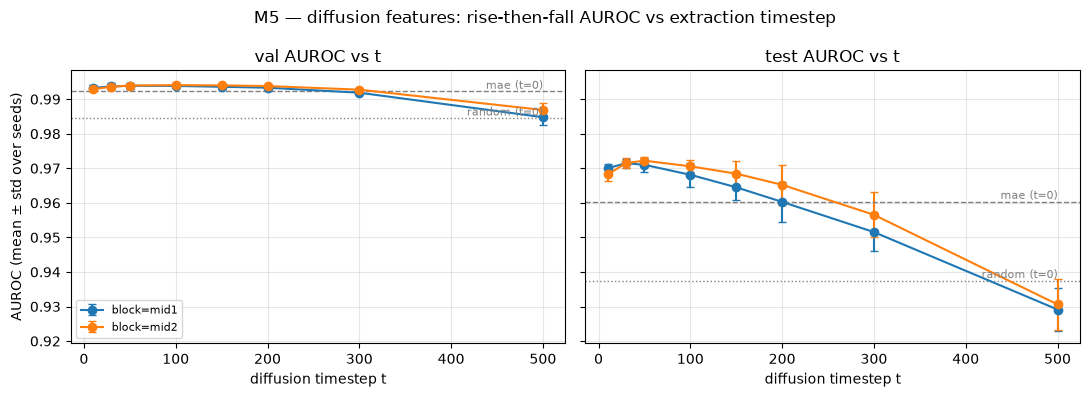


[M5] val-selected diffusion operating point: t=100, block=mid2 (val AUROC 0.9941) -> used for the final table

### M5 — diffusion probe AUROC by timestep

| t   | val mid1      | val mid2      | test mid1     | test mid2     |
|-----|---------------|---------------|---------------|---------------|
| 10  | 0.993 ± 0.001 | 0.993 ± 0.001 | 0.970 ± 0.001 | 0.968 ± 0.002 |
| 30  | 0.994 ± 0.001 | 0.994 ± 0.000 | 0.971 ± 0.001 | 0.972 ± 0.002 |
| 50  | 0.994 ± 0.001 | 0.994 ± 0.000 | 0.971 ± 0.002 | 0.972 ± 0.001 |
| 100 | 0.994 ± 0.001 | 0.994 ± 0.001 | 0.968 ± 0.003 | 0.971 ± 0.002 |
| 150 | 0.994 ± 0.001 | 0.994 ± 0.000 | 0.965 ± 0.004 | 0.968 ± 0.004 |
| 200 | 0.993 ± 0.000 | 0.994 ± 0.000 | 0.960 ± 0.006 | 0.965 ± 0.006 |
| 300 | 0.992 ± 0.000 | 0.993 ± 0.000 | 0.952 ± 0.006 | 0.957 ± 0.007 |
| 500 | 0.985 ± 0.002 | 0.987 ± 0.002 | 0.929 ± 0.006 | 0.931 ± 0.007 |


In [18]:
ABL_TS = list(CFG.ablation.timesteps)
ABL_BLOCKS = list(CFG.ablation.blocks)

for block in ABL_BLOCKS:
    for t in ABL_TS:
        for run in PRETRAINED["diffusion"]:
            r = run_probe_for(run, CFG, t, block)
            print(f"[ablate] block={block:6s} t={t:4d} seed={run['seed']} "
                  f"val AUROC={r['val']['auroc']:.4f}  test AUROC={r['test']['auroc']:.4f}")

# --- plot -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, split in zip(axes, ["val", "test"]):
    for block in ABL_BLOCKS:
        ms, ss = [], []
        for t in ABL_TS:
            (m, s), _ = agg("diffusion", "probe", split, t=t, block=block)
            ms.append(m)
            ss.append(s)
        ax.errorbar(ABL_TS, ms, yerr=ss, marker="o", capsize=3, label=f"block={block}")
    for arm, style in (("mae", "--"), ("random", ":")):
        if arm in list(PRETRAINED) + ["random"]:
            (m, s), n = agg(arm, "probe", split, t=0, block=BLOCK)
            if n:
                ax.axhline(m, ls=style, color="gray", lw=1)
                ax.text(ABL_TS[-1], m, f" {arm} (t=0)", va="bottom", ha="right", fontsize=8,
                        color="gray")
    ax.set_xlabel("diffusion timestep t")
    ax.set_title(f"{split} AUROC vs t")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("AUROC (mean ± std over seeds)")
axes[0].legend(fontsize=8)
fig.suptitle("M5 — diffusion features: rise-then-fall AUROC vs extraction timestep")
fig.tight_layout()
fig.savefig(FIG_DIR / "m5_auroc_vs_timestep.png", dpi=140)
plt.show()

# --- select the operating point on VAL only (I6) ----------------------------------
_cands = []
for block in ABL_BLOCKS:
    for t in ABL_TS:
        (m, s), n = agg("diffusion", "probe", "val", t=t, block=block)
        if n:
            _cands.append((m, t, block))
BEST_VAL_AUROC, BEST_T, BEST_BLOCK = max(_cands)
print(f"\n[M5] val-selected diffusion operating point: t={BEST_T}, block={BEST_BLOCK} "
      f"(val AUROC {BEST_VAL_AUROC:.4f}) -> used for the final table")

M5_TABLE = print_table(
    "M5 — diffusion probe AUROC by timestep",
    [[t] + [cell("diffusion", "probe", "val", t=t, block=b) for b in ABL_BLOCKS]
     + [cell("diffusion", "probe", "test", t=t, block=b) for b in ABL_BLOCKS] for t in ABL_TS],
    ["t"] + [f"val {b}" for b in ABL_BLOCKS] + [f"test {b}" for b in ABL_BLOCKS])

# M6 — fine-tuning + the final table

Same fine-tune recipe for every arm, only the initialization differs (I5). By default
`finetune.use_arm_t: false`, so **all** arms are fine-tuned on clean inputs — the pretrained
weights are treated purely as an initialization. Flip `use_arm_t` to fine-tune the diffusion
arm at its selected `t` instead.

Expect MAE to gain more from fine-tuning than from linear probing (masked reconstruction
produces a strong *initialization* whose frozen bottleneck is less linearly separable). If
that is what the numbers say, that is what the table shows.

In [19]:
FT_T = {arm: (BEST_T if (arm == "diffusion" and CFG.finetune.use_arm_t) else 0)
        for arm in PRETRAINED}

for arm, runs in PRETRAINED.items():
    for run in runs:
        state = {k: v.cpu() for k, v in run["encoder"].state_dict().items()}
        res = finetune(CFG, run["seed"], encoder_state=state, t=FT_T[arm],
                       block=(BEST_BLOCK if arm == "diffusion" else BLOCK),
                       label_frac=1.0, tag=f"{arm}-s{run['seed']}", verbose=False)
        for split in ("val", "test"):
            log_row(arm=arm, protocol="finetune", split=split, seed=run["seed"], t=FT_T[arm],
                    block=(BEST_BLOCK if arm == "diffusion" else BLOCK), pool=CFG.encoder.pool,
                    label_frac=1.0, pretrain_steps=run.get("steps", 0),
                    pretrain_wall_s=round(run.get("wall_s", 0), 1),
                    eval_wall_s=round(res["wall_s"], 1), n_encoder_params=ENCODER_PARAMS,
                    **{k: round(res[split][k], 5) for k in ("auroc", "auprc", "acc", "f1")})
        print(f"[finetune] {arm:9s} seed={run['seed']} t={FT_T[arm]} "
              f"val {fmt_metrics(res['val'])} | test {fmt_metrics(res['test'])}")
        del res

# also fine-tune the random init at 100% labels == supervised-100 (already logged in M4)

# ---------------------------------------------------------------- final table ------
FINAL_ROWS = []
for arm in PRETRAINED:
    t_probe = BEST_T if arm == "diffusion" else 0
    b_probe = BEST_BLOCK if arm == "diffusion" else BLOCK
    FINAL_ROWS.append([
        arm, f"t={t_probe}/{b_probe}" if arm == "diffusion" else "t=0",
        cell(arm, "probe", "test", t=t_probe, block=b_probe),
        cell(arm, "probe", "test", t=t_probe, block=b_probe, metric="auprc"),
        cell(arm, "finetune", "test", t=FT_T[arm],
             block=(BEST_BLOCK if arm == "diffusion" else BLOCK)),
        cell(arm, "finetune", "test", t=FT_T[arm],
             block=(BEST_BLOCK if arm == "diffusion" else BLOCK), metric="auprc"),
    ])
FINAL_ROWS.append(["random-init", "t=0",
                   cell("random", "probe", "test", t=0, block=BLOCK),
                   cell("random", "probe", "test", t=0, block=BLOCK, metric="auprc"), "—", "—"])
for frac in CFG.baselines.label_fractions:
    a = f"supervised-{int(frac * 100)}"
    FINAL_ROWS.append([a, "t=0", "—", "—",
                       cell(a, "finetune", "test"), cell(a, "finetune", "test", metric="auprc")])

FINAL_TABLE = print_table(
    f"M6 — FINAL: test metrics, mean ± std over seeds {list(CFG.eval.seeds)} "
    f"(selection on val only)",
    FINAL_ROWS,
    ["arm", "feature site", "probe AUROC", "probe AUPRC", "finetune AUROC", "finetune AUPRC"])

(RESULTS_DIR / "tables.md").write_text(
    "\n\n".join([M4_TABLE, M5_TABLE, FINAL_TABLE,
                 f"\nencoder params (identical across arms): {ENCODER_PARAMS:,}",
                 f"pretrain budget: {CFG.pretrain.steps} steps @ batch {CFG.data.batch_size}",
                 f"val-selected diffusion operating point: t={BEST_T}, block={BEST_BLOCK}"]))
print(f"\nwrote {RESULTS_DIR / 'tables.md'} and {RESULTS_CSV}")

[finetune] diffusion seed=0 t=0 val AUROC=0.9977  AUPRC=0.9992  ACC=0.9809  F1=0.9872 | test AUROC=0.9731  AUPRC=0.9811  ACC=0.8526  F1=0.8943
[finetune] diffusion seed=1 t=0 val AUROC=0.9972  AUPRC=0.9990  ACC=0.9733  F1=0.9818 | test AUROC=0.9766  AUPRC=0.9843  ACC=0.9167  F1=0.9373
[finetune] diffusion seed=2 t=0 val AUROC=0.9970  AUPRC=0.9990  ACC=0.9828  F1=0.9884 | test AUROC=0.9807  AUPRC=0.9868  ACC=0.8926  F1=0.9209
[finetune] mae       seed=0 t=0 val AUROC=0.9972  AUPRC=0.9991  ACC=0.9752  F1=0.9832 | test AUROC=0.9751  AUPRC=0.9835  ACC=0.8862  F1=0.9160
[finetune] mae       seed=1 t=0 val AUROC=0.9974  AUPRC=0.9991  ACC=0.9752  F1=0.9831 | test AUROC=0.9739  AUPRC=0.9801  ACC=0.8910  F1=0.9192
[finetune] mae       seed=2 t=0 val AUROC=0.9970  AUPRC=0.9990  ACC=0.9771  F1=0.9844 | test AUROC=0.9771  AUPRC=0.9847  ACC=0.9038  F1=0.9275
[finetune] jepa      seed=0 t=0 val AUROC=0.9956  AUPRC=0.9985  ACC=0.9676  F1=0.9778 | test AUROC=0.9581  AUPRC=0.9730  ACC=0.8782  F1=0.9087

# M7 — JEPA arm (phase 2, optional)

Set `jepa.enabled: true` in the config cell and re-run from *Setup 1*. The arm is already
implemented (`JEPAArm`): context encoder = the shared trunk, target encoder = an EMA copy of
the same class/config, prediction in latent space with a small conv predictor. It flows
through `pretrain_arm` / `features_for` / `linear_probe` / `finetune` exactly like the other
arms, so it appears in every table above automatically — no code changes needed.

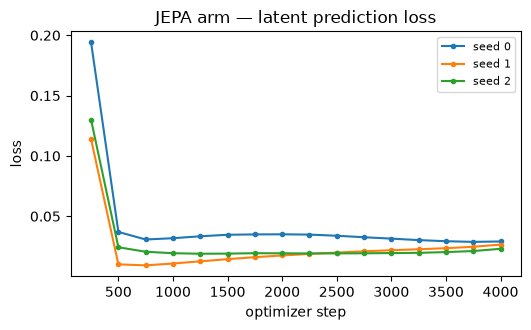

JEPA rows are already included in the M4/M6 tables above.


In [20]:
if CFG.jepa.enabled:
    plot_loss_curves(PRETRAINED["jepa"], "JEPA arm — latent prediction loss",
                     FIG_DIR / "m7_jepa_loss.png")
    print("JEPA rows are already included in the M4/M6 tables above.")
else:
    print("JEPA is disabled (jepa.enabled: false). "
          "Flip it in the config cell and re-run the notebook to include it.")

## Summary / README

The cell below writes a `README.md` next to the notebook describing the design, the
invariants, how to run each milestone, and how to read the two headline outputs.

In [21]:
README = f"""# ssl-medical-compare — controlled comparison of SSL objectives on medical images

One question: **holding the encoder and compute budget fixed, how do self-supervised
objectives compare as medical-image representation learners, and at what abstraction level
(diffusion timestep) does the denoising objective peak?**

Everything lives in `ssl_medical_compare.ipynb`; run it top to bottom. Outputs land in
`{CFG.project.results_dir}/` (CSV + `tables.md` + `figures/`) and `{CFG.project.ckpt_dir}/`.

## Design

* **Dataset** — PneumoniaMNIST (`medmnist`), official train/val/test splits, {CFG.data.size}x{CFG.data.size},
  grayscale, normalized to [-1, 1]. The dataset is imbalanced, so **AUROC and AUPRC are the
  primary metrics**; the BCE loss is class-weighted identically for every arm.
* **Shared encoder** — a small conv U-Net trunk (base {CFG.encoder.base}, mults {list(CFG.encoder.ch_mults)},
  GroupNorm + SiLU, {CFG.encoder.n_mid} mid blocks), {ENCODER_PARAMS:,} parameters, always carrying a
  sinusoidal timestep embedding injected as FiLM. Non-diffusion arms pass `t=0`.
* **Arms** — diffusion (DDPM, T={CFG.diffusion.T}, {CFG.diffusion.schedule} schedule, eps-prediction),
  MAE/SimMIM (patch {CFG.mae.patch_size}, mask ratio {CFG.mae.mask_ratio}), JEPA (implemented, disabled by default).
* **Downstream** — frozen linear probe, then full fine-tune, identical recipe for every arm,
  plus supervised-from-scratch baselines at 100% and 10% labels and a random-init probe control.

## Invariants (the scientific point)

| # | Invariant | Enforcement |
|---|---|---|
| I1 | one shared encoder class + config | `build_encoder()`; `assert_param_parity()` compares count *and* (name, shape) signature |
| I2 | one feature-extraction site | `Encoder.extract()` / `extract_features()`; only `t` varies |
| I3 | pretraining is label-blind, train split only | `UnlabeledImageDataset` holds no labels; `label_blind()` makes labeled reads raise |
| I4 | matched compute budget | one `pretrain:` config block: {CFG.pretrain.steps} steps, AdamW, warmup+cosine, for every arm |
| I5 | matched downstream protocol | `probe:` / `finetune:` config blocks; the functions take no per-arm hyperparameters |
| I6 | honest test discipline | seeds {list(CFG.eval.seeds)}, mean ± std, selection on val, test evaluated once per config |

## Milestones

| cell | does |
|---|---|
| M0 | data shapes, class balance, sample grid, label-leakage assertion |
| M1 | encoder construction + parameter-parity assertion |
| M2 | train the DDPM, sample images, show the forward process at the probed timesteps |
| M3 | train SimMIM, visualize reconstructions |
| M4 | linear probes for every arm + random control + supervised baselines -> first table |
| M5 | timestep/block ablation -> `figures/m5_auroc_vs_timestep.png`, val-selected `t` |
| M6 | fine-tune every arm -> final arm x {{probe, finetune}} table |
| M7 | JEPA (optional) |

## Reading the two headline outputs

**The table** (`{CFG.project.results_dir}/tables.md`). Compare *within a column*: the probe column
answers "how linearly separable is the frozen bottleneck", the finetune column answers "how good
an initialization is this". A pretrained arm only earns a claim if it beats **both** the
random-init probe control and supervised-10%.

**The AUROC-vs-t plot** (`figures/m5_auroc_vs_timestep.png`). Expect rise-then-fall. Small `t`:
the denoiser only has to fix fine detail, so features are texture-level. Mid `t`: the task
requires reconstructing structure that is genuinely gone, which forces semantic features —
this is where the curve should peak. Large `t`: the input is mostly noise, the model falls back
on the prior, and the features stop describing *this* image. That peak is why you never extract
at `t -> T`, and the ablation is meant to *show* it rather than assume it.

## Running

```bash
export PYTORCH_ENABLE_MPS_FALLBACK=1     # some ops have no MPS kernel
jupyter lab                              # then: Restart & Run All
```

Leave `SMOKE = True` for a full end-to-end dry run on a subset (~2 min), then set it to
`False` for the real run. Measured on an M-series laptop (MPS, batch {CFG.data.batch_size} @ {CFG.data.size}px):
~0.43 s/step for diffusion and ~0.37 s/step for MAE, i.e. ~30 min per arm per seed at
{CFG.pretrain.steps} steps (~3 h for the full grid) plus ~30 min for fine-tunes, baselines and the
sweep. To shorten it, cut `eval.seeds` to `[0]` or lower `pretrain.steps` **for every arm at
once** — a per-arm budget would break I4. Checkpoints are reused across runs; pass `force=True` to
`pretrain_arm` to retrain. Determinism is not guaranteed on MPS, which is why every number is
reported as mean ± std over {len(list(CFG.eval.seeds))} seed(s).

## Known asymmetry (flagged, not hidden)

The diffusion decoder keeps U-Net skip connections while the MAE decoder does not
(`diffusion.decoder_skips` / `mae.decoder_skips`). Skips let a denoiser route detail *around*
the bottleneck we probe; removing them from DDPM hurts sample quality. Both are config flags,
so the effect is measurable rather than assumed.

## Non-goals

Not a reproduction of full OrthoDiffusion (3D, three orientation models, 16k volumes). No
cross-backbone comparisons (that would violate I1). No test-split model selection.
"""
Path("README.md").write_text(README)
print(README[:1500], "\n...\n[wrote README.md]")

# ssl-medical-compare — controlled comparison of SSL objectives on medical images

One question: **holding the encoder and compute budget fixed, how do self-supervised
objectives compare as medical-image representation learners, and at what abstraction level
(diffusion timestep) does the denoising objective peak?**

Everything lives in `ssl_medical_compare.ipynb`; run it top to bottom. Outputs land in
`results/` (CSV + `tables.md` + `figures/`) and `checkpoints/`.

## Design

* **Dataset** — PneumoniaMNIST (`medmnist`), official train/val/test splits, 64x64,
  grayscale, normalized to [-1, 1]. The dataset is imbalanced, so **AUROC and AUPRC are the
  primary metrics**; the BCE loss is class-weighted identically for every arm.
* **Shared encoder** — a small conv U-Net trunk (base 32, mults [1, 2, 4, 8],
  GroupNorm + SiLU, 2 mid blocks), 4,058,656 parameters, always carrying a
  sinusoidal timestep embedding injected as FiLM. Non-diffusion arms pass `t=0`.
* **Arms** — diffusion (DDPM, 